#Исследовательский анализ данных для хакатона

##Загрузка библиотек и написание своих функций

In [1]:
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.cluster.hierarchy as sch
from scipy.spatial.distance import squareform

from sklearn.preprocessing import StandardScaler

pd.set_option('display.max_columns', None)
import warnings
warnings.filterwarnings('ignore', module='pandas')
warnings.simplefilter(action='ignore', category=FutureWarning)

#ограничение вывода экспонинцеального вывода чисел
np.set_printoptions(suppress=True)

In [2]:
pip install --upgrade gdown

In [3]:
#функция для изучения данных на аномальные значения и попуски
#функция принимает на вход DataFrame, выводит текстовые сообщения на консоль
def anomaly(data):
  #сли передан Series, преобразуем его в DataFrame
  if isinstance(data, pd.Series):
    data = data.to_frame()
  #выводим размер датасета
  print(f'Размер файла:{data.shape}')
  print('-'*100)
  #для вывода всех столбцов создаем цикл
  #выделяем в отдельную переменную названия столбцов
  column_data= data.columns
  #циклом перебираем все значения и выводим данные
  for c in column_data:
    #выводим все уникальные значения
    print(f'Уникальные значения показателя: {c}')
    print(data[c].unique())
    #считаем количество уникальных значений
    print(f'Количество уникальных значений: {data[c].nunique()}')
    #считаем количество всех значений
    print(f'Количество всех значений: {data[c].count()}')
    #считаем количество пропусков
    print(f'Количество пропусков в столбце {c}: {data[c].isna().sum()}')
    print('-'*100)

In [4]:
#функция для исследовательского анализа количественных данных
#функция принимает на вход DataFrame (количественные данные), выводит графики на консоль
def analisys_num(data):
    fig, axes = plt.subplots(1, 3, figsize=(10, 5))

    #настраиваем построение гистограммы
    axes[0].hist(data.dropna(), bins=20)
    axes[0].set_title('Гистограмма показателя')
    axes[0].set_xlabel('Значения показателя')
    #визуально выводим среднее значение и медиану
    axes[0].axvline(data.median(), color='b', linestyle='dashed', linewidth=2)
    axes[0].axvline(data.mean(), color='r', linestyle='solid', linewidth=2)
    axes[0].legend(['Медиана', 'Среднее', 'Мода'], prop={'size': 6})

    #постройка боксплота для данных
    axes[1].set_title('Боксплот показателя')
    axes[1].boxplot(data.dropna())
    #настройка скрипичной диаграммы
    axes[2].set_title('Скрипичная диаграмма показателя')
    axes[2].violinplot([data.dropna()], vert=False, widths=0.75,
                       showmeans=True, showmedians=True)
    plt.tight_layout()
    plt.show()
    #выводим статистику по показателю
    print('Показатели описательной статистики')
    print(data.describe())
    print(f'Мода в данных по показателю: {data.mode()}')

In [5]:
#функция для исследовательского анализа качественных данных с использованием круговой диаграммы
#функция принимает данные и считает их количество внутри каждого уникального значения,
#после выводит круговой график
#функция принимает на вход DataFrame, выводит графики на консоль
def analisys_cat_pie(data, labels=None):
    if labels is not None:
      data = data.map(labels)

    data.value_counts().plot(kind='pie', autopct='%.2f%%', figsize=(5, 5))
    plt.title('Круговая диаграмма показателя', size=10)
    plt.show()

In [6]:
#функция для исследовательского анализа качевтенных данных с использованием столбчатой диаграммы
#функция принимает данные и считает их количество внутри каждого уникального значения,
#после выводит столбчатую диаграмму
#функция принимает на вход DataFrame, выводит графики на консоль
def analisys_cat_plot(data):
    data.value_counts(ascending=True).plot(kind='bar', alpha=0.8)
    plt.title('Столбчатая диаграмма', size=15)
    plt.xlabel('Количество', size=12)
    plt.ylabel('Значения', size=12)
    plt.show()

In [7]:
#функция для вывода графика Lmplot
#функция принимает датасет и названия столбцов, по которым надо построить график
#функция принимает на вход DataFrame, выводит графики сообщения на консоль
def grafic(data, x, y):
    sns.lmplot(x=x, y=y, data=data)
    plt.title(f'Зависимость показателя {y} от показателя {x}', size=10)
    plt.xlabel(f'Показатель {x}', size=8)
    plt.ylabel(f'Показатель {y}', size=8)
    plt.show()

In [8]:
#функция для изучения распределния показателя в группах по целевому признаку
#функция принимает числовые данные для каждой группы и строит боксплот
def target_sigh(data, target_col, sign_col):
  sns.boxplot(x=target_col, y=sign_col, data=data)
  plt.title(f'Сравнение показателя {sign_col} у пациентов')
  plt.xlabel('Показатель')
  plt.show()

In [9]:
#функция для изучения распределения категориального фактора внутри группы целевого признака
#функция принимает количество категориальых данных в группе и строит гистограмму
def target_group(data, target_col, sign_col):
  plot_grouped_data(data, group_cols=[target_col, sign_col],
      rename_dict={
          'index': {0: 'Нет', 1: 'Есть'}
      }
  )
  plt.show()

##Загрузка данных и первичная оценка

In [10]:
#! gdown 1kjLbbEWXDnYqm42hCzz7VE1DzcbyVUdD

In [11]:
! gdown 1VsgvD17YarR6QNb51mMeNC50UnahVldE

Downloading...
From: https://drive.google.com/uc?id=1VsgvD17YarR6QNb51mMeNC50UnahVldE
To: /content/work_df_2.csv
100% 456k/456k [00:00<00:00, 7.71MB/s]


In [12]:
#work_df = pd.read_csv('/content/work_df.csv')

In [13]:
work_df = pd.read_csv('/content/work_df_2.csv')

In [14]:
#словарь с синонимами, которые использовались при предподготовке данный с указанными нормами
replacement_dict = {
    # Красная кровь
    'rbc': ['Эритроциты', 'Эритроциты (RBC)', 'Общее количество эритроцитов (RBC)', 'RBC'],
    'hgb': ['Гемоглобин', 'Гемоглобин (HGB)', 'HGB'],
    #размерность гемоглобина г/дл
    'hct': ['Гематокрит', 'Гематокрит (HCT)', 'HCT'],
    'mcv': ['Средний объем эритроцита', 'Средний объем эритроцита (MCV)', 'MCV'],
    'mch': ['Среднее содержание гемоглобина в эритроците', 'Среднее содержание гемоглобина в эритроците (MCH)', 'MCH'],
    'mchc': ['Средняя концентрация гемоглобина в эритроците', 'Средняя концентрация гемоглобина в эритроците (MCHC)', 'MCHC'],
    'rdw': ['Ширина распределения эритроцитов', 'Ширина распределения эритроцитов по объему (RDW)', 'RDW', 'Ширина распределения эритроцитов (RDW)'],
    'rdv_cv': ['Ширина распределения эритроцитов по объему, коэффициент вариации (RDW-CV)', 'Ширина распределения эритроцитов по объему, коэффициент вариации', 'RDW-CV '],
    'rdv_sd': ['Ширина распределения эритроцитов по объему, стандартное отклонение (RDW-SD)','Ширина распределения эритроцитов по объему, стандартное отклонение','Ширина распределения эритроцитов, стандартное отклонение (RDW-SD)', 'RDW-SD'],
    'ret_rel': ['RET%', 'Ретикулоциты %'],
    'ret_abs': ['Ретикулоциты кол-во'],
    'cp': ['Цветовой показатель'],

    # Белая кровь
    'wbc': ['Лейкоциты', 'Лейкоциты (WBC)', 'Общее количество лейкоцитов (WBC)', 'WBC'], #размерность 10*9/л

    # Лейкоформула
    'ne_abs': ['Нейтрофилы, абсолютное количество', 'Нейтрофилы, абсолютное количество (NE#)', 'Абсолютное количество нейтрофилов (NE#)', 'Нейтрофилы #'],
    'ne_rel': ['Нейтрофилы, относительное количество', 'Нейтрофилы, относительное количество (NE%)', 'Относительное количество нейтрофилов (NE%)', 'Нейтрофилы %', 'NE%'],
    'ly_abs': ['Лимфоциты, абсолютное количество', 'Лимфоциты, абсолютное количество (LY#)', 'Лимфоциты', 'Абсолютное количество лимфоцитов (LY#)', 'Лимфоциты #'],
    'ly_rel': ['Лимфоциты, относительное количество', 'Лимфоциты, относительное количество (LY%)', 'Лимфоциты %', 'Относительное количество лимфоцитов (LY%)', 'Лимфоциты %', 'LY%'],
    'mo_abs': ['Моноциты, абсолютное количество', 'Моноциты, абсолютное количество (MO#)', 'Моноциты', 'Абсолютное количество моноцитов (MO#)', 'Моноциты #'],
    'mo_rel': ['Моноциты, относительное количество', 'Моноциты, относительное количество (MO%)', 'Моноциты %', 'Моноциты %', 'Относительное количество моноцитов (MO%)', 'MO%'],
    'eo_abs': ['Эозинофилы, абсолютное количество', 'Эозинофилы, абсолютное количество (EO#)', 'Эозинофилы', 'Абсолютное количество эозинофилов (EO#)', 'Эозинофилы # '],
    #размерность абсолюного количества 10*9/л
    'eo_rel': ['Эозинофилы, относительное количество', 'Эозинофилы, относительное количество (EO%)', 'Эозинофилы %', 'Относительное количество эозинофилов (EO%)', 'EO%'],
    'ba_abs': ['Базофилы, абсолютное количество', 'Базофилы, абсолютное количество (BA#)', 'Базофилы', 'Абсолютное количество базофилов (BA#)', 'Базофилы #', 'Базофилы # '],
    'ba_rel': ['Базофилы, относительное количество', 'Базофилы, относительное количество (BA%)', 'Базофилы %', 'Относительное количество базофилов (BA%)', 'BA%'],
    'pal': ['Палочкоядерные'],
    'seg': ['Сегментоядерные'],
    'mxd_abs': ['Смешанная фракция, абсолютное количество (MXD#)', 'MXD# ', 'Смешанная фракция, абсолютное количество', 'MXD#', 'MXD'],
    'mxd_rel': ['Смешанная фракция, относительное количество (MXD%)', 'MXD%', 'Смешанная фракция, относительное количество'],
    'plasma': ['Плазматические клетки', 'Плазматич. клетки'], # в норме - 0-1%

    # Тромбоциты
    'plt': ['Тромбоциты', 'Тромбоциты (PLT)', 'PLT'],
    'pct': ['Тромбокрит', 'Тромбокрит (PCT)', 'PCT'],
    'mpv': ['Средний объем тромбоцита', 'Средний объём тромбоцитов', 'Средний объем тромбоцита (MPV)', 'MPV (Средний объём тромбоцитов)', 'MPV ', 'MPV'],
    'pdw': ['Ширина распределения тромбоцитов', 'Ширина распределения тромбоцитов по объему', 'Ширина распределения тромбоцитов (PDW)', 'PDW'],
    'plcr': ['P-LCR'],


    'soe': ['СОЭ Вест.', 'Скорость оседания эритроцитов (СОЭ) по Вестергрену', 'СОЭ по Панченкову', 'СОЭ Панч.'],

    'myelo': ['Миелоциты'], # в норме - 0 появление в периферической крови всегда указывает на патологию
    'yunye': ['Юные'], # в норме - 0 всегда требует обследования
    'blasty': ['Бласты'], # в норме - 0 опухолевые клетки, лейкоз
    'normobl_abs': ['Нормобласты', 'Нормобласты #'], # в норме - 0
    'normobl_rel': ['Нормобласты %'], # в норме - 0
    'prolym': ['Пролимфоциты'], # в норме - 0 "красный флаг", требующий исключения злокачественных заболеваний крови! в датасете в %
    'promyelo': ['Промиелоциты'], # в норме - 0  тревожный сигнал, требующий исключения лейкозов и других тяжелых заболеваний крови

    'noclass_abs': ['Неклассифицируемые кол-во'],
    'noclass_rel': ['Неклассифицируемые %'],
}


In [15]:
anomaly(work_df)

Размер файла:(3115, 52)
----------------------------------------------------------------------------------------------------
Уникальные значения показателя: study_ID
['05deb1af-cf40-11e9-80ba-901b0e633689_result_1802'
 '05deb1af-cf40-11e9-80ba-901b0e633689_result_1803'
 '05deb1af-cf40-11e9-80ba-901b0e633689_result_1805' ...
 'ffdf0ad3-bb5b-11ee-ab6f-0050568844e6_result_2593'
 'ffdf0ad3-bb5b-11ee-ab6f-0050568844e6_result_2594'
 'ffdf0ad3-bb5b-11ee-ab6f-0050568844e6_result_2595']
Количество уникальных значений: 3115
Количество всех значений: 3115
Количество пропусков в столбце study_ID: 0
----------------------------------------------------------------------------------------------------
Уникальные значения показателя: ba_abs
[0.    nan 0.22 0.15 0.1  0.14 0.17 0.31 0.06 0.07 0.08 0.09 0.04 0.11
 0.2  0.41 0.02 0.52 0.21 0.34 0.39 0.38 0.72 0.03 0.24 0.05 0.5  0.29
 0.19 0.26 0.01 0.12 0.33 0.25 0.37 0.16 0.36 0.28 0.32 0.23 0.44 0.42
 0.13 0.51 0.18 0.66 0.27 0.4  0.58 0.35 0.3  0.6  7.

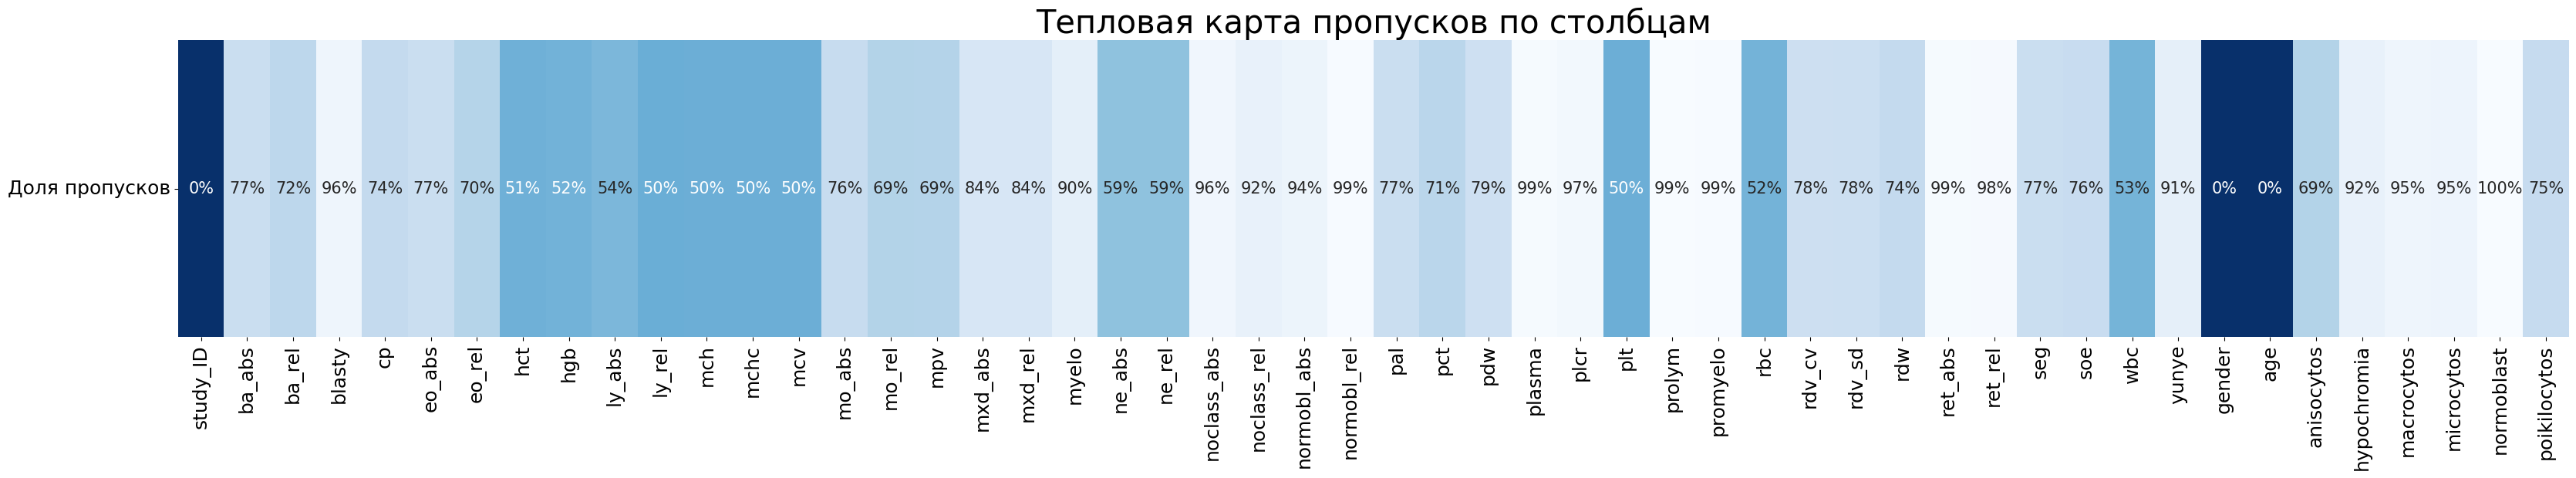

In [16]:
mask = work_df.isna()

prop_missings = mask.sum()/mask.count()

#преобразуем в DataFrame для построения тепловой карты
df_prop_missings = pd.DataFrame(prop_missings.values.reshape(1, -1),
                                columns=prop_missings.index,
                                index=['Доля пропусков'])

#тепловая карта пропусков
plt.figure(figsize=(40, 5))
sns.heatmap(df_prop_missings, annot=True, fmt='.0%',
            cmap='Blues_r', cbar=False, annot_kws={'fontsize': 15})
plt.title("Тепловая карта пропусков по столбцам", fontsize=30)
plt.xticks(fontsize=18)
plt.yticks(fontsize=18, rotation=0)
plt.show()

In [17]:
#столбцы-кандидаты на удаление в связи с пропусками более 90 %
col_del = ['blasty', 'myelo', 'noclass_abs', 'noclass_rel', 'noclass_abs', 'plasma', 'plcr',
'prolym', 'ret_abs', 'ret_rel', 'yunye', 'hypochromia', ' microcytos']

##Исследовательский анализ

In [18]:
work_df.columns

Index(['study_ID', 'ba_abs', 'ba_rel', 'blasty', 'cp', 'eo_abs', 'eo_rel',
       'hct', 'hgb', 'ly_abs', 'ly_rel', 'mch', 'mchc', 'mcv', 'mo_abs',
       'mo_rel', 'mpv', 'mxd_abs', 'mxd_rel', 'myelo', 'ne_abs', 'ne_rel',
       'noclass_abs', 'noclass_rel', 'normobl_abs', 'normobl_rel', 'pal',
       'pct', 'pdw', 'plasma', 'plcr', 'plt', 'prolym', 'promyelo', 'rbc',
       'rdv_cv', 'rdv_sd', 'rdw', 'ret_abs', 'ret_rel', 'seg', 'soe', 'wbc',
       'yunye', 'gender', 'age', 'anisocytos', 'hypochromia', 'macrocytos',
       'microcytos', 'normoblast', 'poikilocytos'],
      dtype='object')

In [19]:
bool_col = ['gender', 'promyelo', 'anisocytos', 'hypochromia',
            'macrocytos','microcytos', 'normoblast', 'poikilocytos', 'normobl_rel']
cat_col = ['prolym', 'promyelo']

num_col = ['ba_abs', 'ba_rel', 'blasty', 'cp', 'eo_abs', 'eo_rel',
           'hct', 'hgb', 'ly_abs', 'ly_rel', 'mch', 'mchc', 'mcv', 'mo_abs',
           'mo_rel', 'mpv', 'mxd_abs', 'mxd_rel', 'myelo', 'ne_abs', 'ne_rel',
           'noclass_abs', 'noclass_rel', 'normobl_abs', 'pal',
           'pct', 'pdw', 'plasma', 'plcr', 'plt', 'rbc',
           'rdv_cv', 'rdv_sd', 'rdw', 'ret_abs', 'ret_rel', 'seg', 'soe', 'wbc',
           'yunye']

Исследовательский анализ показателя ba_abs


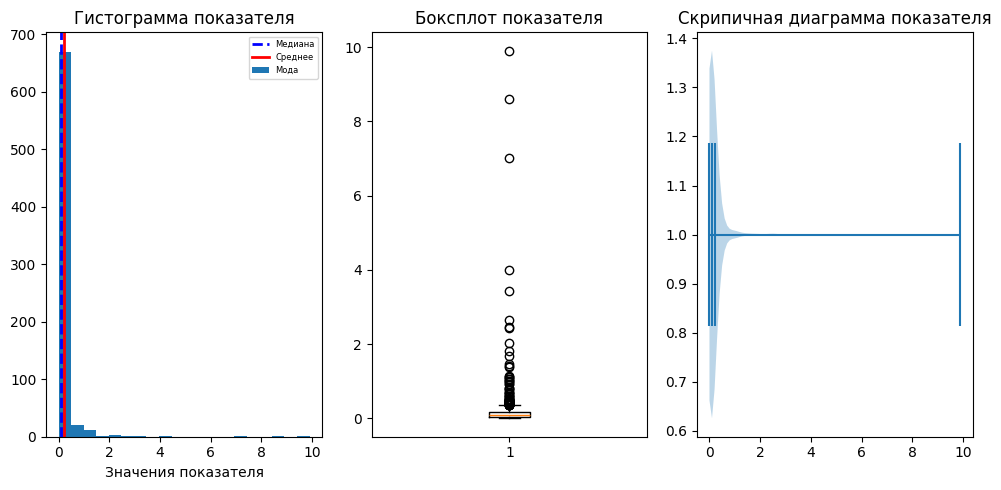

Показатели описательной статистики
count    712.000000
mean       0.201236
std        0.636204
min        0.000000
25%        0.030000
50%        0.100000
75%        0.160000
max        9.900000
Name: ba_abs, dtype: float64
Мода в данных по показателю: 0    0.1
Name: ba_abs, dtype: float64
----------------------------------------------------------------------------------------------------
Исследовательский анализ показателя ba_rel


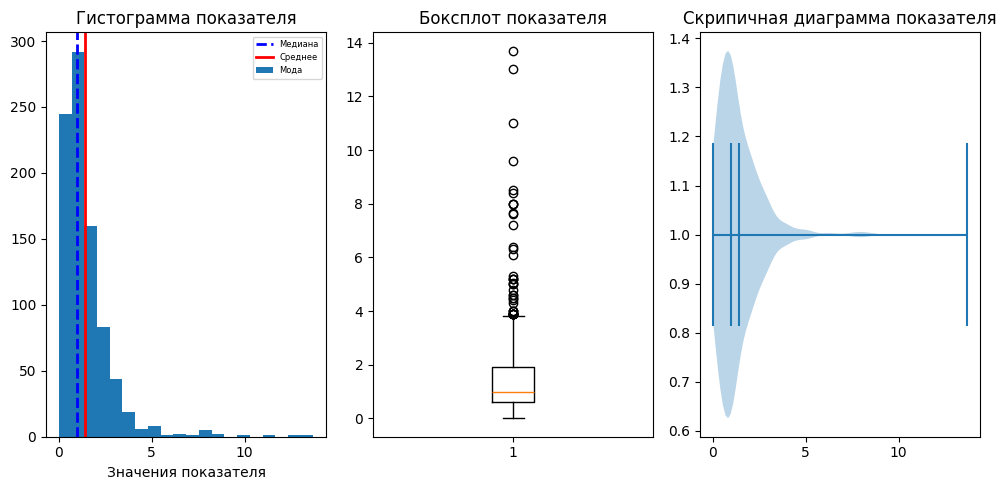

Показатели описательной статистики
count    872.000000
mean       1.427913
std        1.402373
min        0.000000
25%        0.600000
50%        1.000000
75%        1.900000
max       13.700000
Name: ba_rel, dtype: float64
Мода в данных по показателю: 0    1.0
Name: ba_rel, dtype: float64
----------------------------------------------------------------------------------------------------
Исследовательский анализ показателя blasty


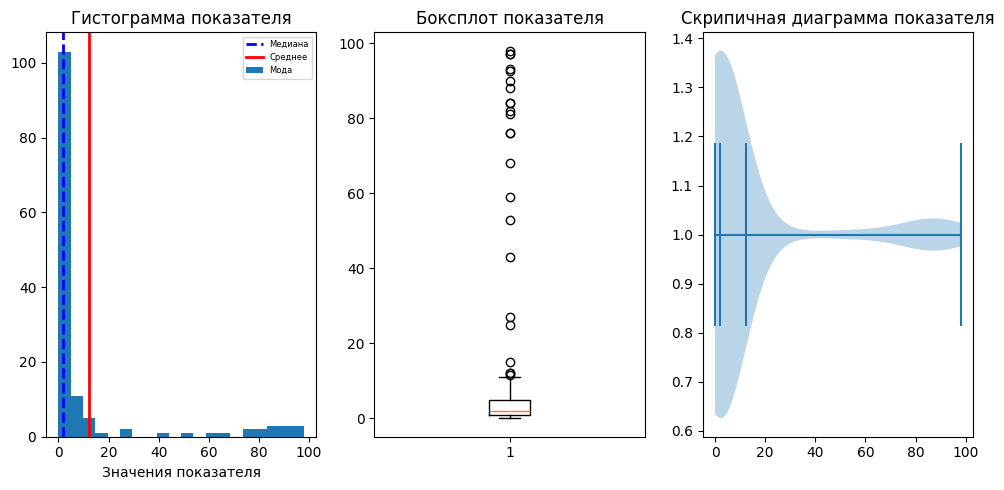

Показатели описательной статистики
count    139.000000
mean      12.320144
std       26.249500
min        0.000000
25%        1.000000
50%        2.000000
75%        5.000000
max       98.000000
Name: blasty, dtype: float64
Мода в данных по показателю: 0    1.0
Name: blasty, dtype: float64
----------------------------------------------------------------------------------------------------
Исследовательский анализ показателя cp


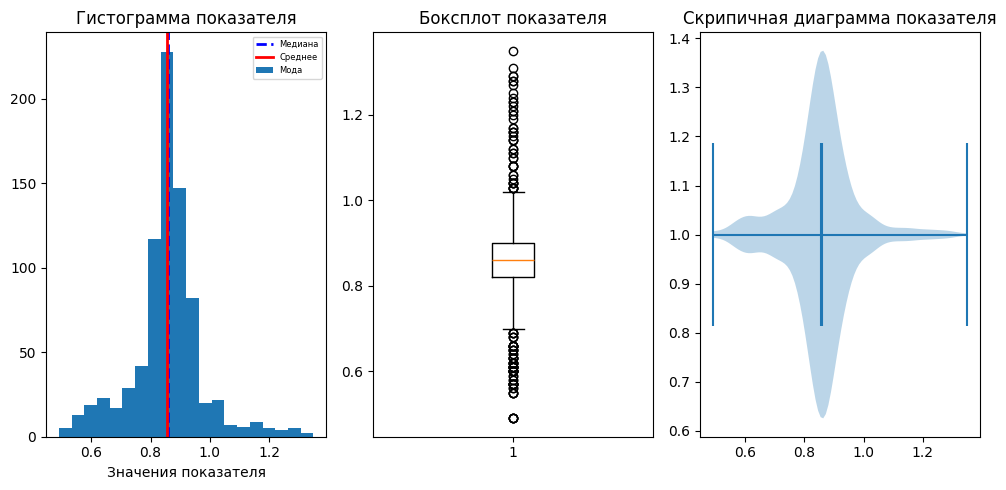

Показатели описательной статистики
count    802.000000
mean       0.856222
std        0.118955
min        0.490000
25%        0.820000
50%        0.860000
75%        0.900000
max        1.350000
Name: cp, dtype: float64
Мода в данных по показателю: 0    0.86
Name: cp, dtype: float64
----------------------------------------------------------------------------------------------------
Исследовательский анализ показателя eo_abs


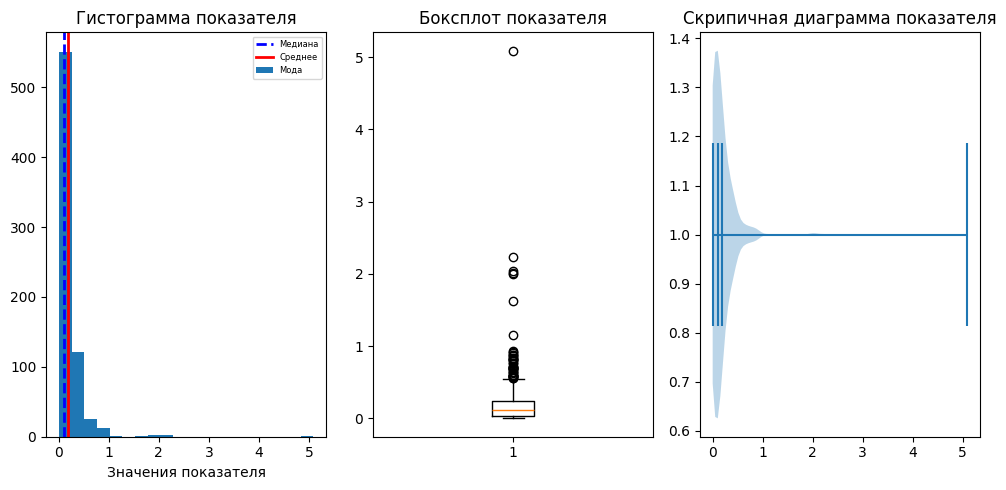

Показатели описательной статистики
count    718.000000
mean       0.191643
std        0.300131
min        0.000000
25%        0.030000
50%        0.110000
75%        0.240000
max        5.090000
Name: eo_abs, dtype: float64
Мода в данных по показателю: 0    0.0
Name: eo_abs, dtype: float64
----------------------------------------------------------------------------------------------------
Исследовательский анализ показателя eo_rel


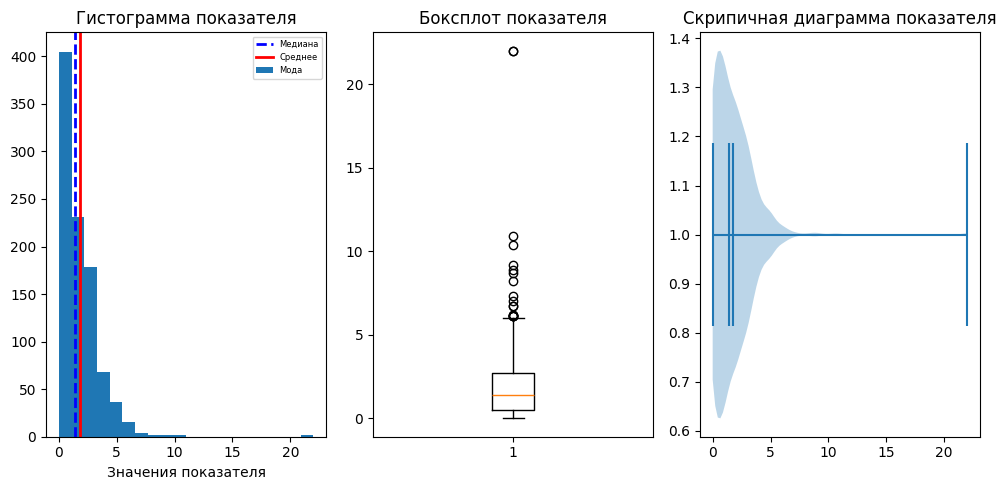

Показатели описательной статистики
count    946.000000
mean       1.794355
std        1.828476
min        0.000000
25%        0.500000
50%        1.400000
75%        2.700000
max       22.000000
Name: eo_rel, dtype: float64
Мода в данных по показателю: 0    0.0
Name: eo_rel, dtype: float64
----------------------------------------------------------------------------------------------------
Исследовательский анализ показателя hct


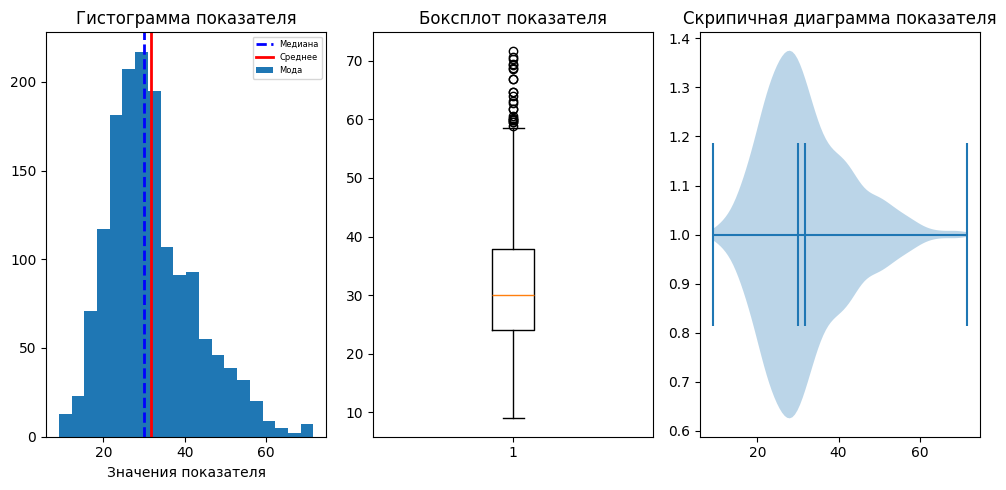

Показатели описательной статистики
count    1530.000000
mean       31.756667
std        10.613300
min         9.000000
25%        24.000000
50%        30.000000
75%        37.900000
max        71.700000
Name: hct, dtype: float64
Мода в данных по показателю: 0    28.0
Name: hct, dtype: float64
----------------------------------------------------------------------------------------------------
Исследовательский анализ показателя hgb


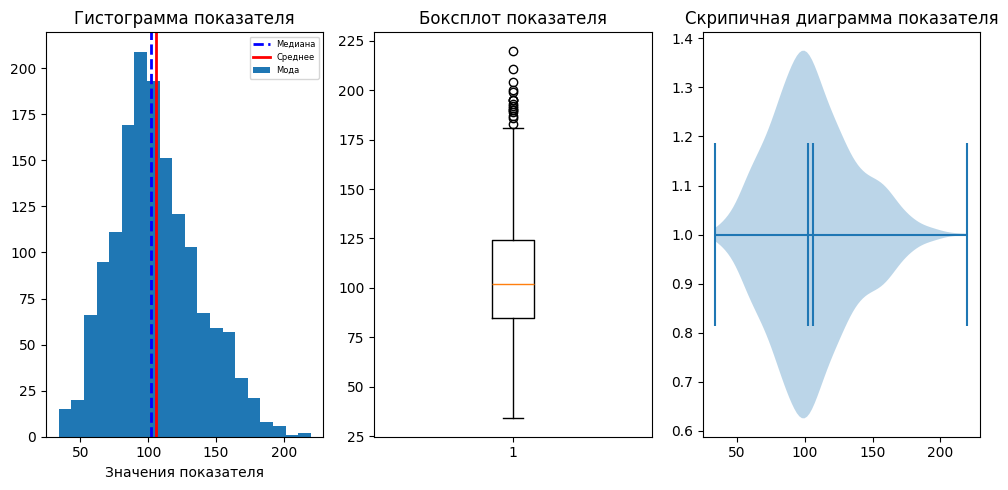

Показатели описательной статистики
count    1506.000000
mean      105.771116
std        31.252131
min        34.000000
25%        85.000000
50%       102.000000
75%       124.000000
max       220.000000
Name: hgb, dtype: float64
Мода в данных по показателю: 0    111.0
Name: hgb, dtype: float64
----------------------------------------------------------------------------------------------------
Исследовательский анализ показателя ly_abs


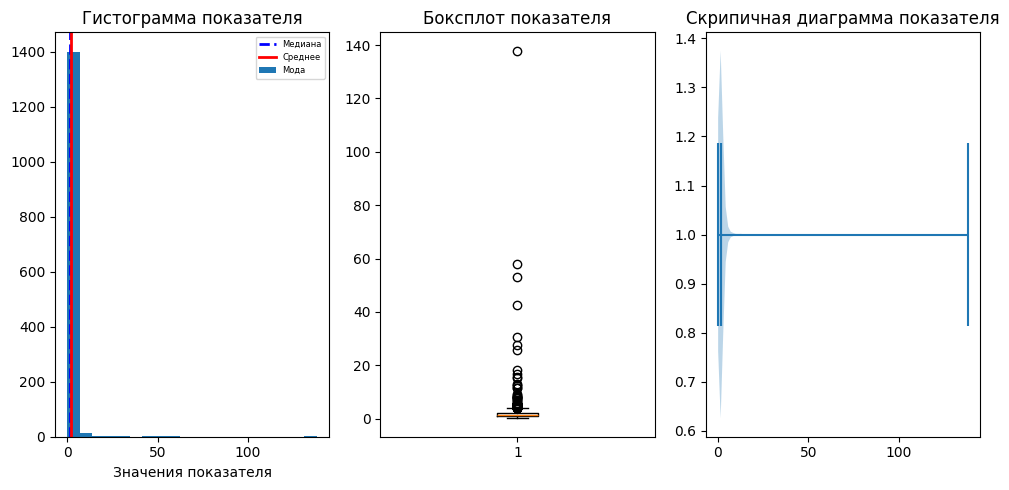

Показатели описательной статистики
count    1427.000000
mean        1.943742
std         4.683656
min         0.100000
25%         0.900000
50%         1.400000
75%         2.100000
max       137.900000
Name: ly_abs, dtype: float64
Мода в данных по показателю: 0    1.0
Name: ly_abs, dtype: float64
----------------------------------------------------------------------------------------------------
Исследовательский анализ показателя ly_rel


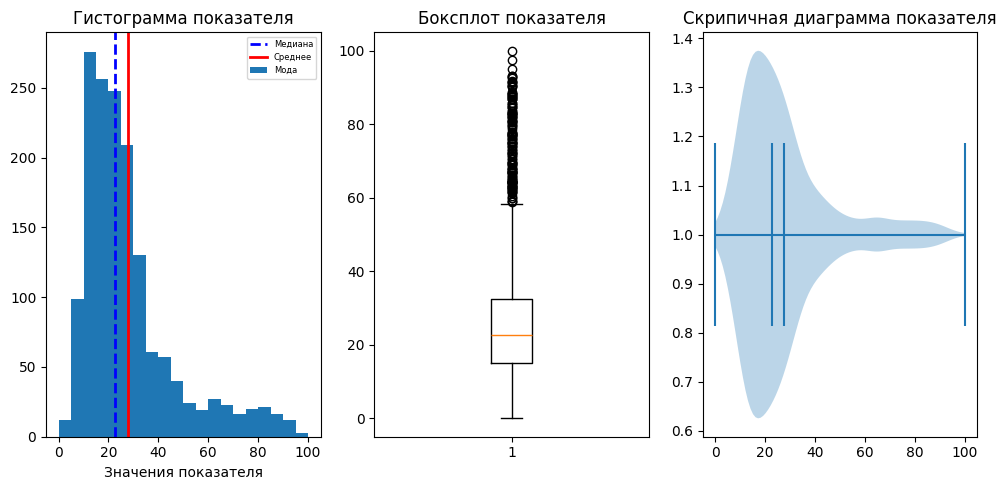

Показатели описательной статистики
count    1569.000000
mean       27.748923
std        18.700423
min         0.000000
25%        15.000000
50%        22.600000
75%        32.500000
max       100.000000
Name: ly_rel, dtype: float64
Мода в данных по показателю: 0    20.0
Name: ly_rel, dtype: float64
----------------------------------------------------------------------------------------------------
Исследовательский анализ показателя mch


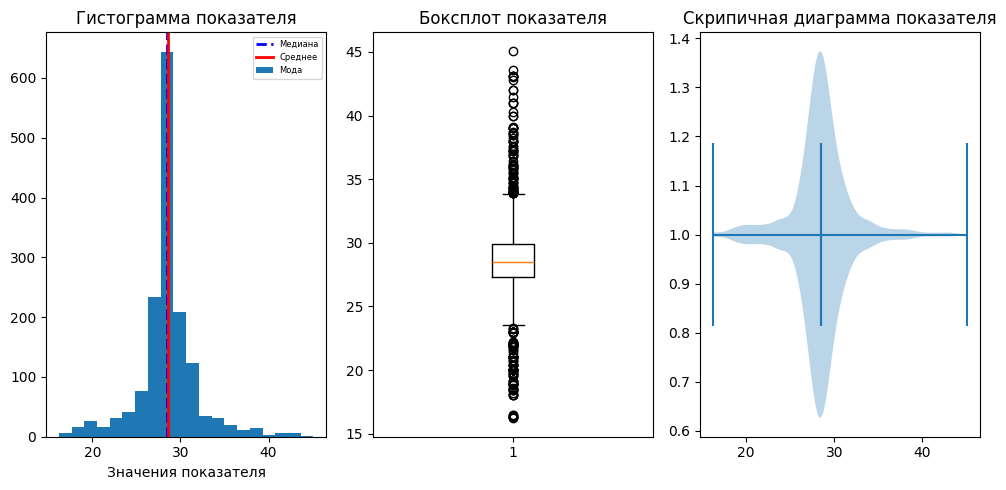

Показатели описательной статистики
count    1551.000000
mean       28.535332
std         3.415419
min        16.200000
25%        27.300000
50%        28.500000
75%        29.900000
max        45.100000
Name: mch, dtype: float64
Мода в данных по показателю: 0    28.0
Name: mch, dtype: float64
----------------------------------------------------------------------------------------------------
Исследовательский анализ показателя mchc


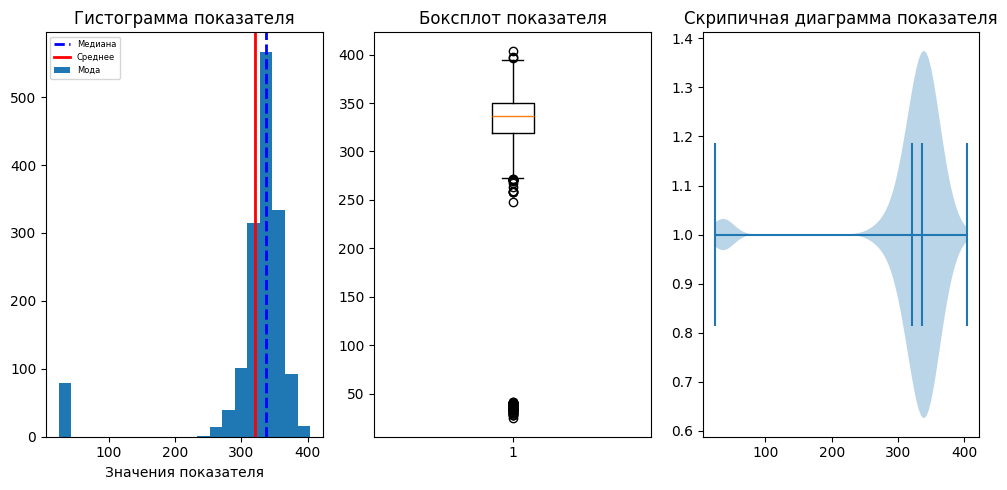

Показатели описательной статистики
count    1558.000000
mean      321.146021
std        69.439907
min        24.400000
25%       319.000000
50%       337.000000
75%       349.750000
max       404.000000
Name: mchc, dtype: float64
Мода в данных по показателю: 0    344.0
Name: mchc, dtype: float64
----------------------------------------------------------------------------------------------------
Исследовательский анализ показателя mcv


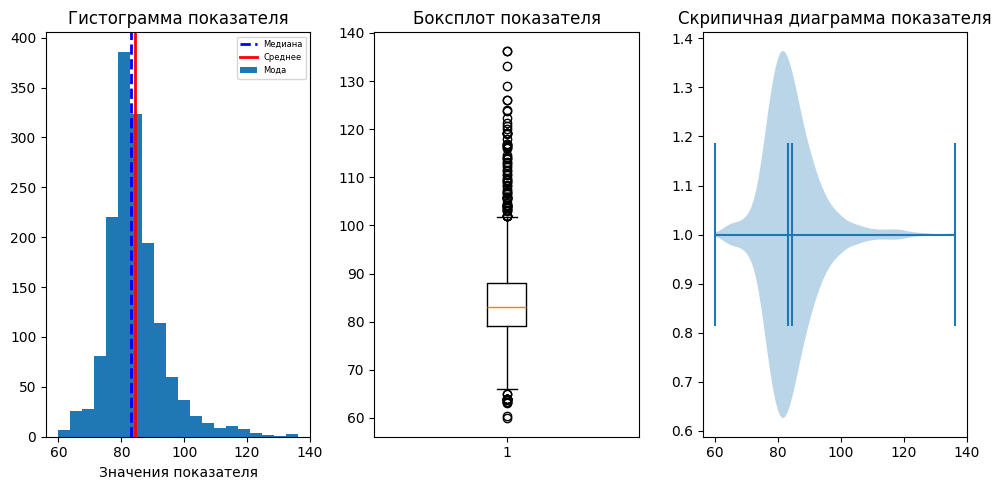

Показатели описательной статистики
count    1549.000000
mean       84.496901
std         9.303803
min        59.900000
25%        79.000000
50%        83.000000
75%        88.100000
max       136.300000
Name: mcv, dtype: float64
Мода в данных по показателю: 0    81.0
Name: mcv, dtype: float64
----------------------------------------------------------------------------------------------------
Исследовательский анализ показателя mo_abs


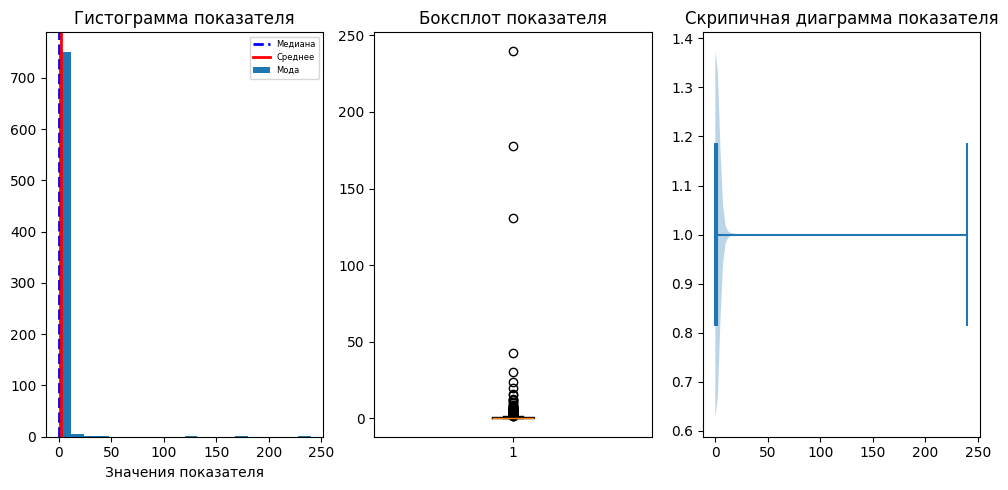

Показатели описательной статистики
count    762.000000
mean       1.782953
std       12.041505
min        0.000000
25%        0.200000
50%        0.400000
75%        0.810000
max      239.930000
Name: mo_abs, dtype: float64
Мода в данных по показателю: 0    0.2
Name: mo_abs, dtype: float64
----------------------------------------------------------------------------------------------------
Исследовательский анализ показателя mo_rel


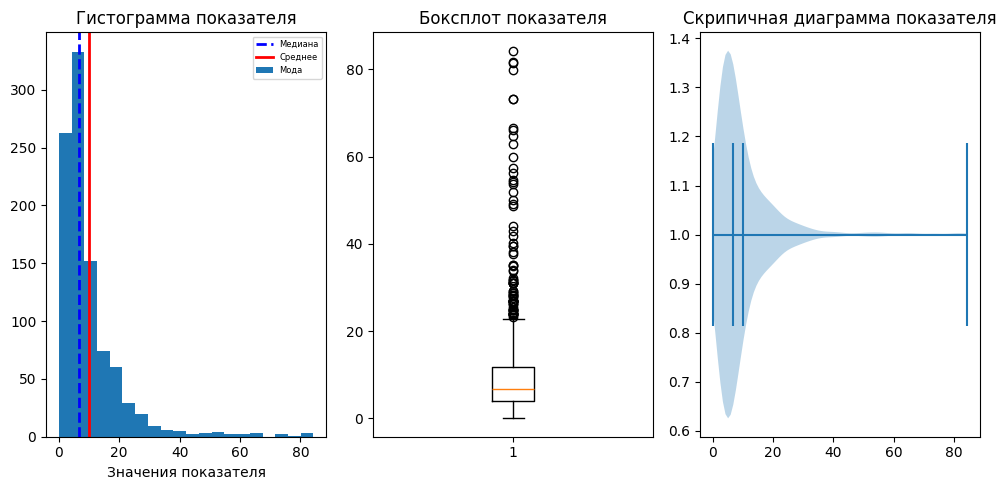

Показатели описательной статистики
count    973.000000
mean      10.024049
std       10.743366
min        0.000000
25%        4.000000
50%        6.700000
75%       11.700000
max       84.300000
Name: mo_rel, dtype: float64
Мода в данных по показателю: 0    5.0
Name: mo_rel, dtype: float64
----------------------------------------------------------------------------------------------------
Исследовательский анализ показателя mpv


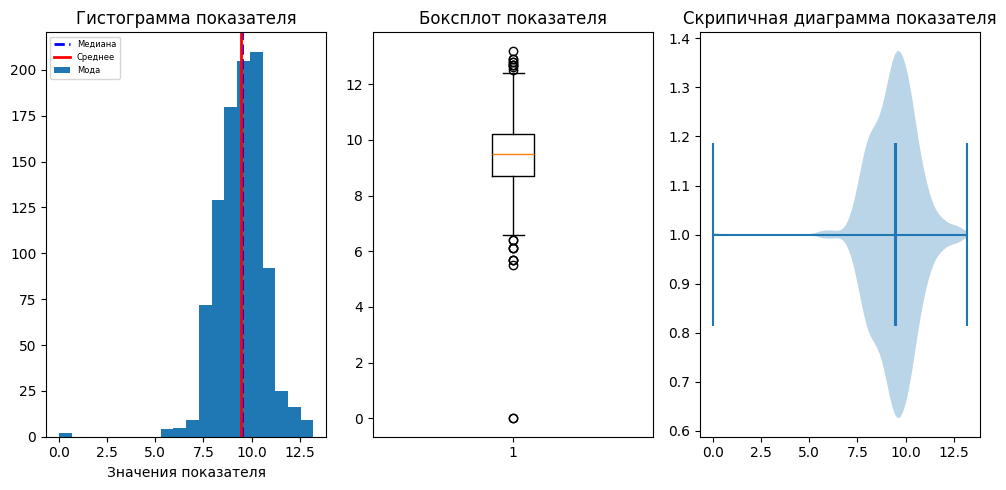

Показатели описательной статистики
count    958.000000
mean       9.430167
std        1.225606
min        0.000000
25%        8.700000
50%        9.500000
75%       10.200000
max       13.200000
Name: mpv, dtype: float64
Мода в данных по показателю: 0    9.5
Name: mpv, dtype: float64
----------------------------------------------------------------------------------------------------
Исследовательский анализ показателя mxd_abs


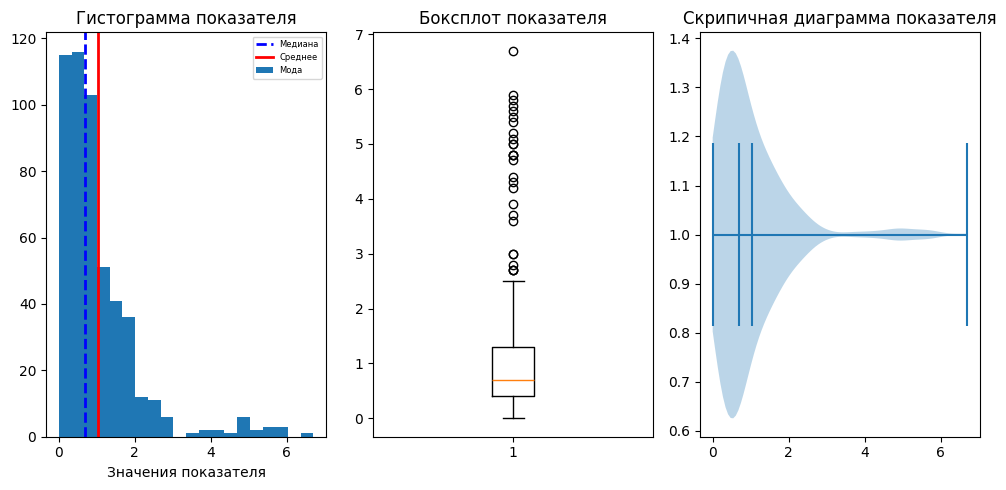

Показатели описательной статистики
count    512.000000
mean       1.026563
std        1.036571
min        0.000000
25%        0.400000
50%        0.700000
75%        1.300000
max        6.700000
Name: mxd_abs, dtype: float64
Мода в данных по показателю: 0    0.6
Name: mxd_abs, dtype: float64
----------------------------------------------------------------------------------------------------
Исследовательский анализ показателя mxd_rel


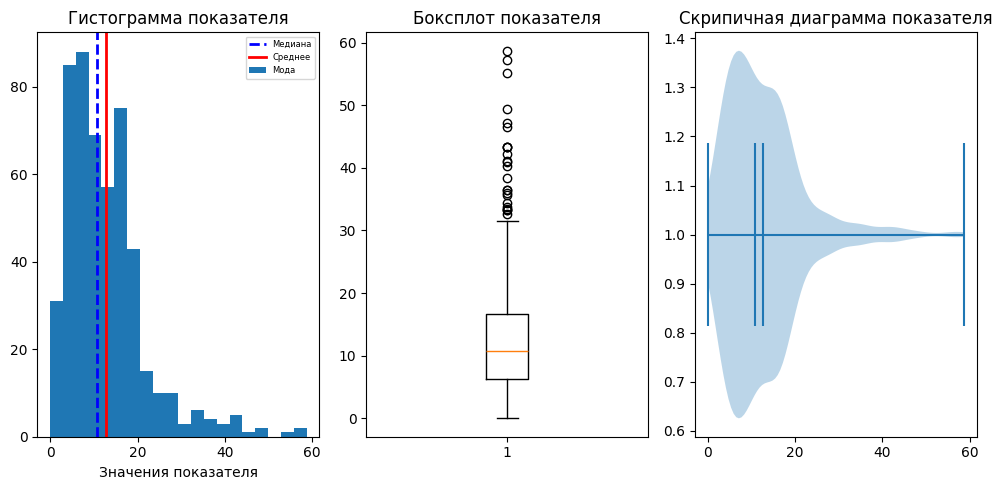

Показатели описательной статистики
count    510.000000
mean      12.743922
std        9.097502
min        0.000000
25%        6.225000
50%       10.700000
75%       16.700000
max       58.700000
Name: mxd_rel, dtype: float64
Мода в данных по показателю: 0    15.3
Name: mxd_rel, dtype: float64
----------------------------------------------------------------------------------------------------
Исследовательский анализ показателя myelo


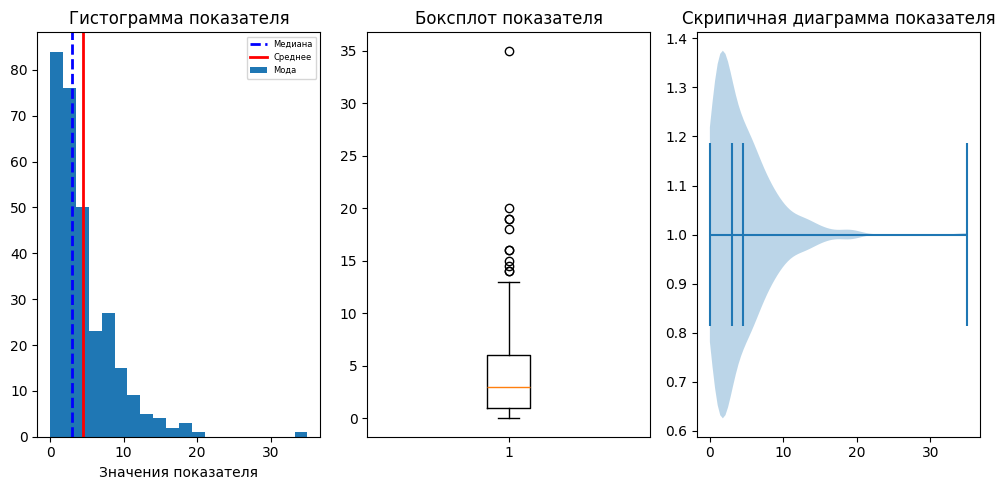

Показатели описательной статистики
count    300.000000
mean       4.467667
std        4.210425
min        0.000000
25%        1.000000
50%        3.000000
75%        6.000000
max       35.000000
Name: myelo, dtype: float64
Мода в данных по показателю: 0    1.0
Name: myelo, dtype: float64
----------------------------------------------------------------------------------------------------
Исследовательский анализ показателя ne_abs


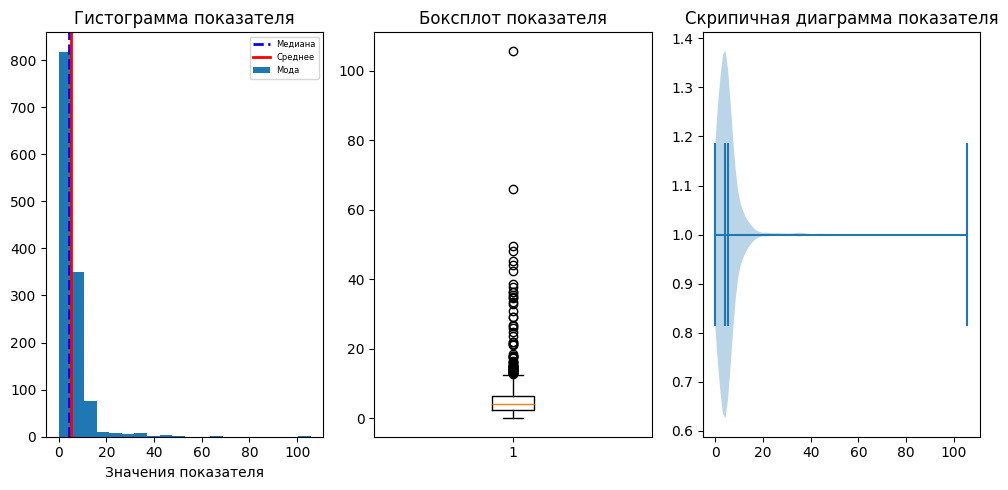

Показатели описательной статистики
count    1281.000000
mean        5.309883
std         6.262694
min         0.000000
25%         2.360000
50%         4.200000
75%         6.480000
max       105.700000
Name: ne_abs, dtype: float64
Мода в данных по показателю: 0    0.3
Name: ne_abs, dtype: float64
----------------------------------------------------------------------------------------------------
Исследовательский анализ показателя ne_rel


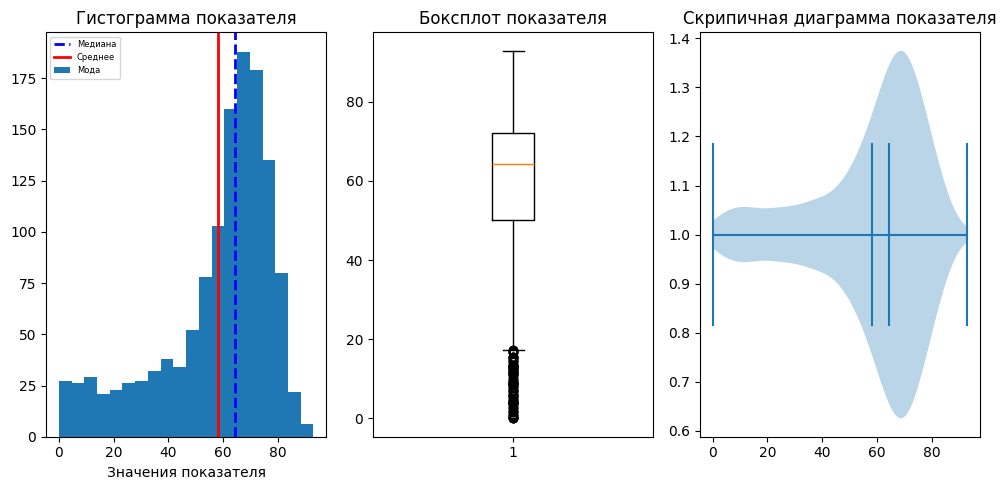

Показатели описательной статистики
count    1286.000000
mean       58.013336
std        20.494704
min         0.000000
25%        50.100000
50%        64.300000
75%        72.000000
max        92.900000
Name: ne_rel, dtype: float64
Мода в данных по показателю: 0    68.6
Name: ne_rel, dtype: float64
----------------------------------------------------------------------------------------------------
Исследовательский анализ показателя noclass_abs


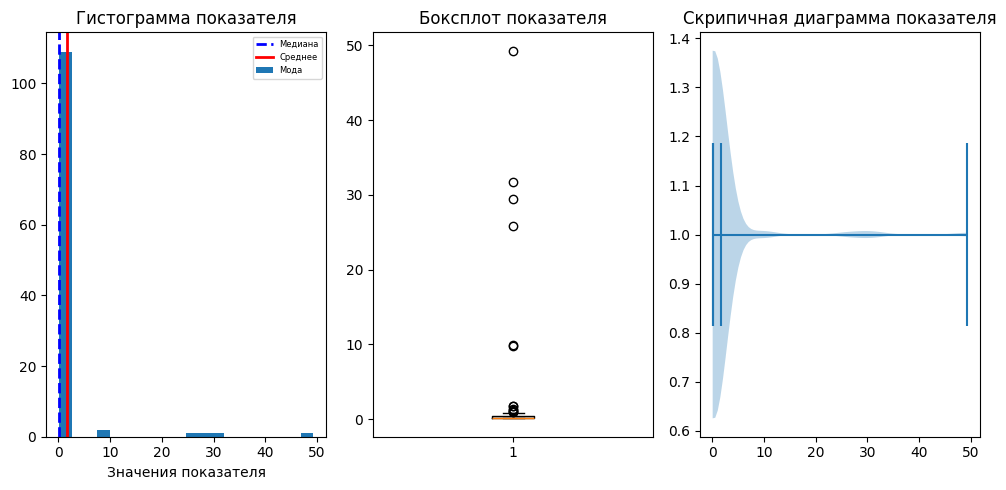

Показатели описательной статистики
count    115.000000
mean       1.654522
std        6.536726
min        0.100000
25%        0.100000
50%        0.200000
75%        0.400000
max       49.300000
Name: noclass_abs, dtype: float64
Мода в данных по показателю: 0    0.1
Name: noclass_abs, dtype: float64
----------------------------------------------------------------------------------------------------
Исследовательский анализ показателя noclass_rel


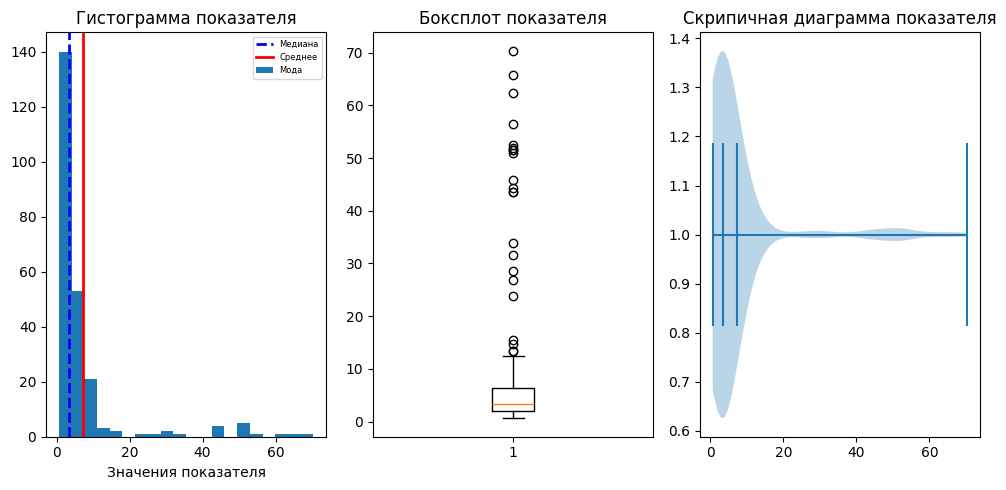

Показатели описательной статистики
count    237.000000
mean       7.176793
std       12.160098
min        0.600000
25%        1.900000
50%        3.400000
75%        6.300000
max       70.400000
Name: noclass_rel, dtype: float64
Мода в данных по показателю: 0    1.9
Name: noclass_rel, dtype: float64
----------------------------------------------------------------------------------------------------
Исследовательский анализ показателя normobl_abs


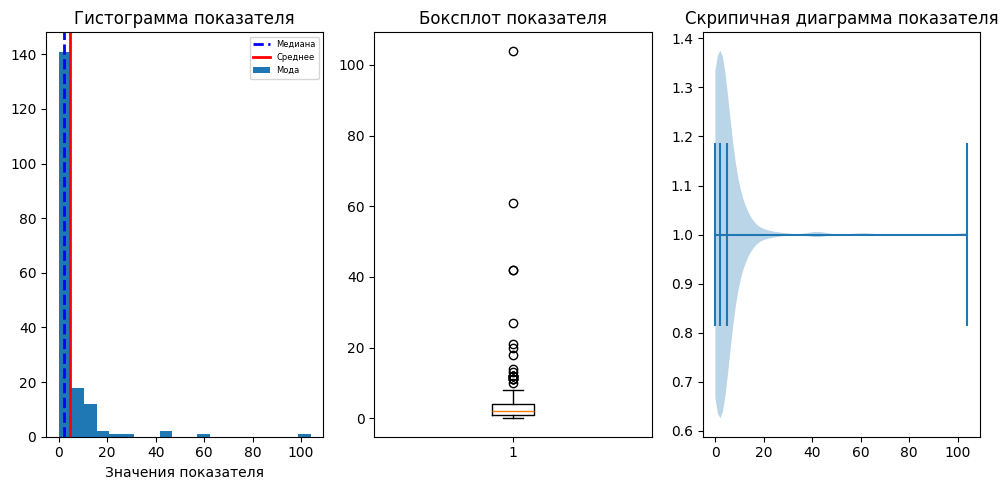

Показатели описательной статистики
count    179.000000
mean       4.759777
std       10.396269
min        0.000000
25%        1.000000
50%        2.000000
75%        4.000000
max      104.000000
Name: normobl_abs, dtype: float64
Мода в данных по показателю: 0    1.0
Name: normobl_abs, dtype: float64
----------------------------------------------------------------------------------------------------
Исследовательский анализ показателя pal


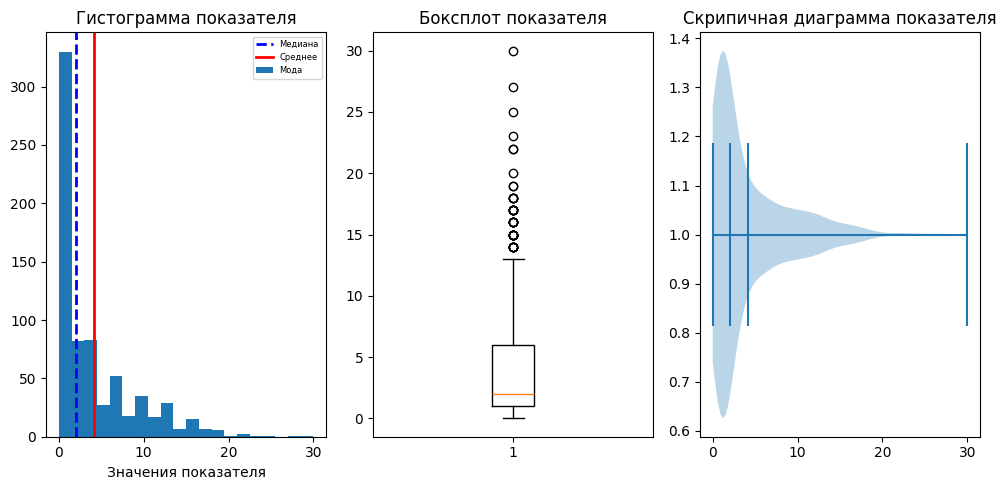

Показатели описательной статистики
count    715.000000
mean       4.146014
std        4.756072
min        0.000000
25%        1.000000
50%        2.000000
75%        6.000000
max       30.000000
Name: pal, dtype: float64
Мода в данных по показателю: 0    1.0
Name: pal, dtype: float64
----------------------------------------------------------------------------------------------------
Исследовательский анализ показателя pct


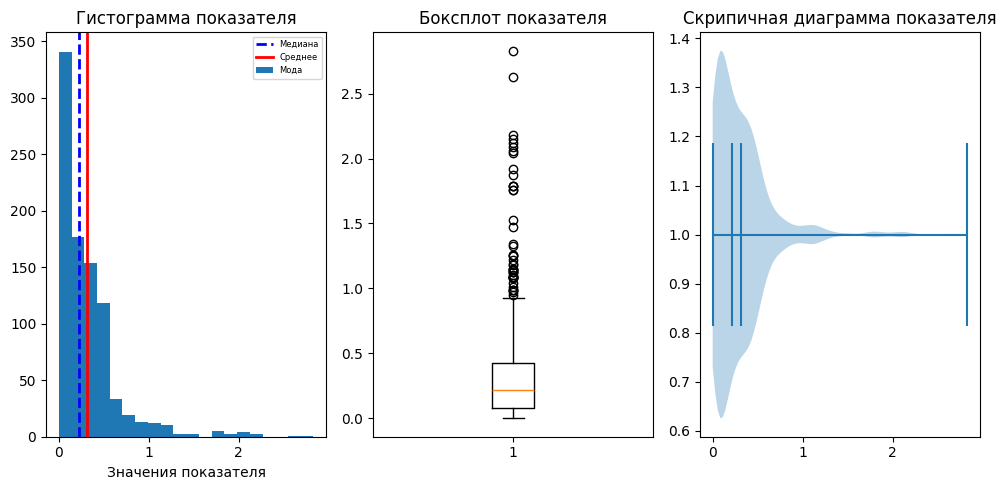

Показатели описательной статистики
count    896.000000
mean       0.312969
std        0.346064
min        0.000000
25%        0.080000
50%        0.220000
75%        0.422500
max        2.830000
Name: pct, dtype: float64
Мода в данных по показателю: 0    0.03
Name: pct, dtype: float64
----------------------------------------------------------------------------------------------------
Исследовательский анализ показателя pdw


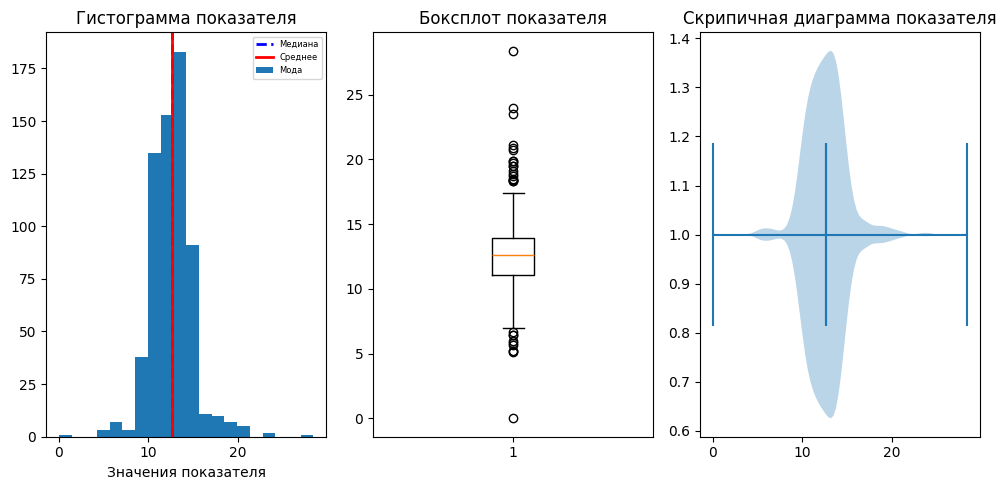

Показатели описательной статистики
count    650.000000
mean      12.622615
std        2.392250
min        0.000000
25%       11.100000
50%       12.600000
75%       13.900000
max       28.400000
Name: pdw, dtype: float64
Мода в данных по показателю: 0    11.7
1    13.5
Name: pdw, dtype: float64
----------------------------------------------------------------------------------------------------
Исследовательский анализ показателя plasma


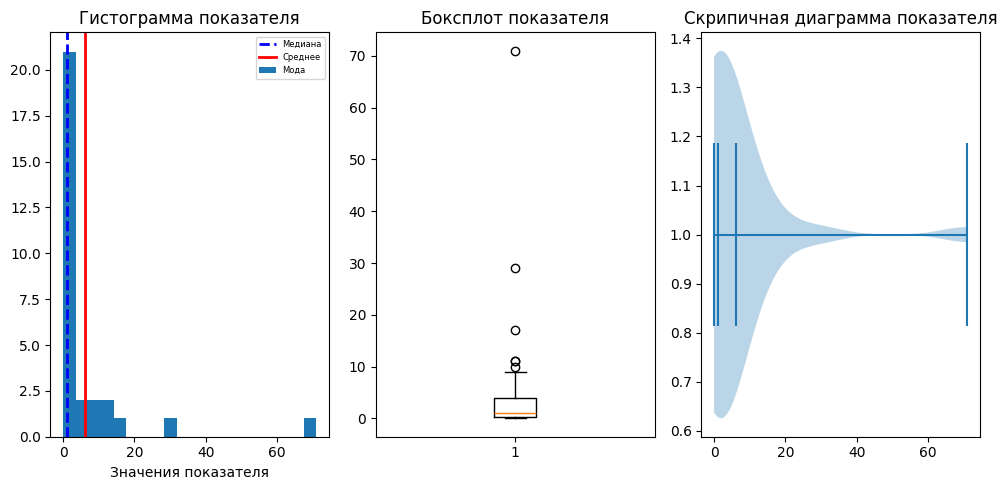

Показатели описательной статистики
count    30.000000
mean      6.166667
std      13.796760
min       0.000000
25%       0.250000
50%       1.000000
75%       4.000000
max      71.000000
Name: plasma, dtype: float64
Мода в данных по показателю: 0    1.0
Name: plasma, dtype: float64
----------------------------------------------------------------------------------------------------
Исследовательский анализ показателя plcr


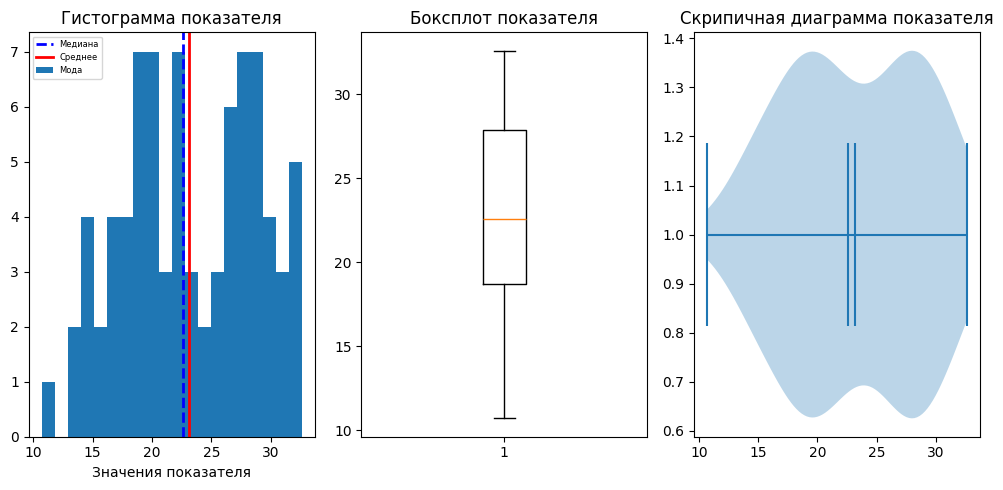

Показатели описательной статистики
count    81.000000
mean     23.154321
std       5.643869
min      10.700000
25%      18.700000
50%      22.600000
75%      27.900000
max      32.600000
Name: plcr, dtype: float64
Мода в данных по показателю: 0    18.7
Name: plcr, dtype: float64
----------------------------------------------------------------------------------------------------
Исследовательский анализ показателя plt


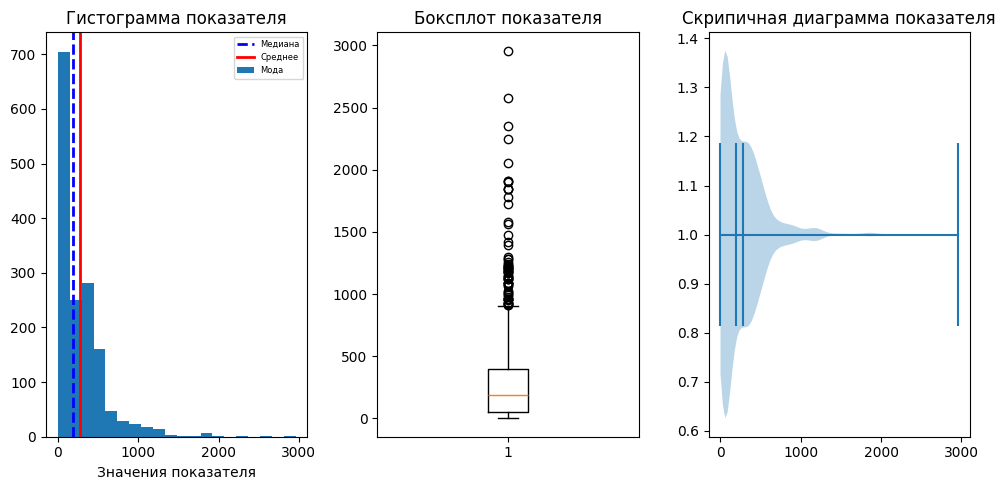

Показатели описательной статистики
count    1548.000000
mean      277.416021
std       311.185310
min         0.000000
25%        55.000000
50%       187.500000
75%       394.250000
max      2958.000000
Name: plt, dtype: float64
Мода в данных по показателю: 0    36.0
Name: plt, dtype: float64
----------------------------------------------------------------------------------------------------
Исследовательский анализ показателя rbc


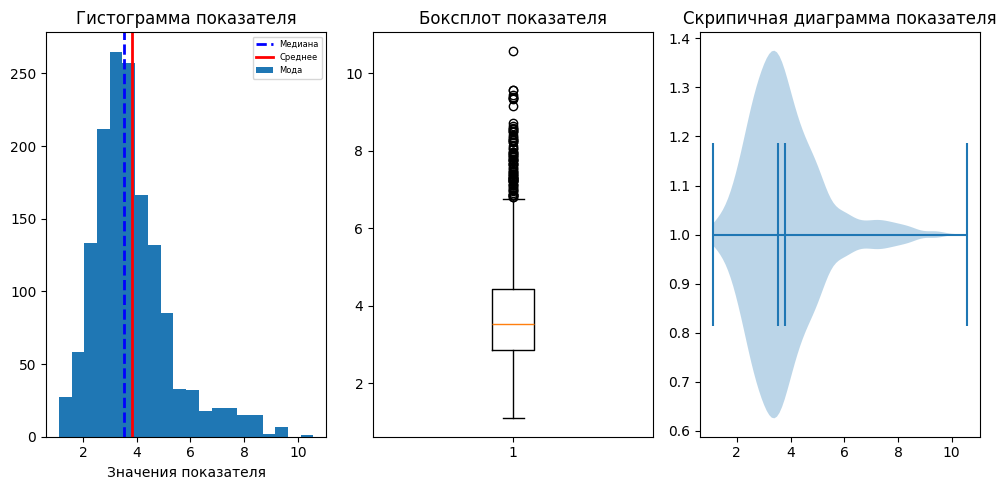

Показатели описательной статистики
count    1498.000000
mean        3.808939
std         1.426445
min         1.100000
25%         2.860000
50%         3.540000
75%         4.430000
max        10.580000
Name: rbc, dtype: float64
Мода в данных по показателю: 0    3.53
1    3.61
2    3.73
Name: rbc, dtype: float64
----------------------------------------------------------------------------------------------------
Исследовательский анализ показателя rdv_cv


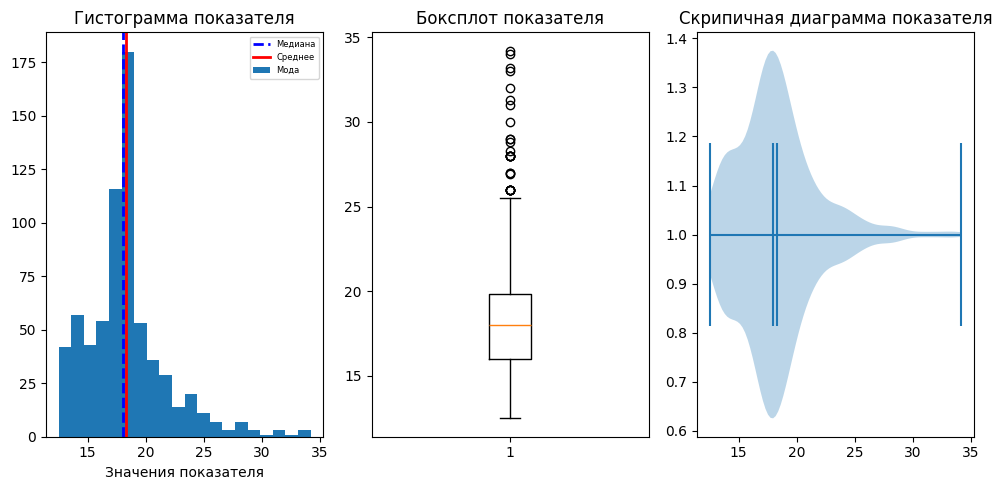

Показатели описательной статистики
count    683.000000
mean      18.307028
std        3.519195
min       12.500000
25%       16.000000
50%       18.000000
75%       19.850000
max       34.200000
Name: rdv_cv, dtype: float64
Мода в данных по показателю: 0    18.0
Name: rdv_cv, dtype: float64
----------------------------------------------------------------------------------------------------
Исследовательский анализ показателя rdv_sd


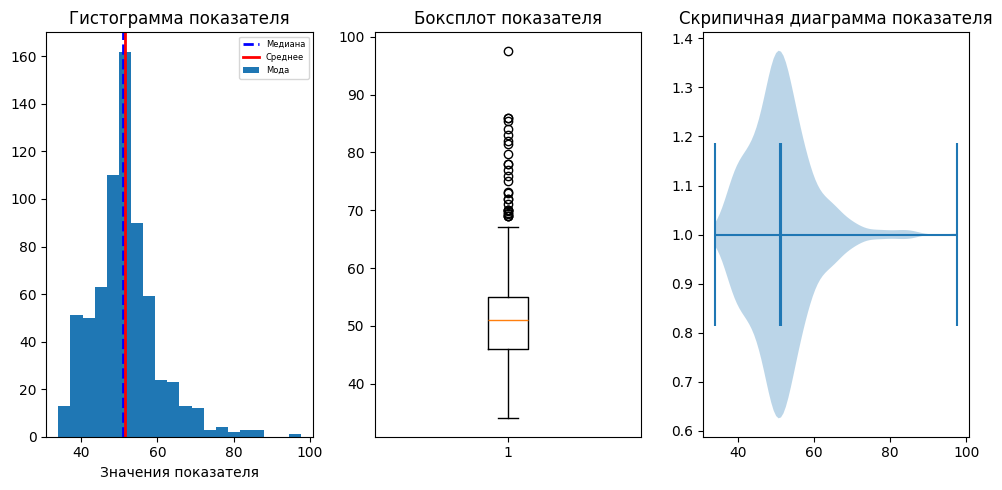

Показатели описательной статистики
count    686.000000
mean      51.473032
std        8.577936
min       34.000000
25%       46.000000
50%       51.000000
75%       55.075000
max       97.600000
Name: rdv_sd, dtype: float64
Мода в данных по показателю: 0    52.0
Name: rdv_sd, dtype: float64
----------------------------------------------------------------------------------------------------
Исследовательский анализ показателя rdw


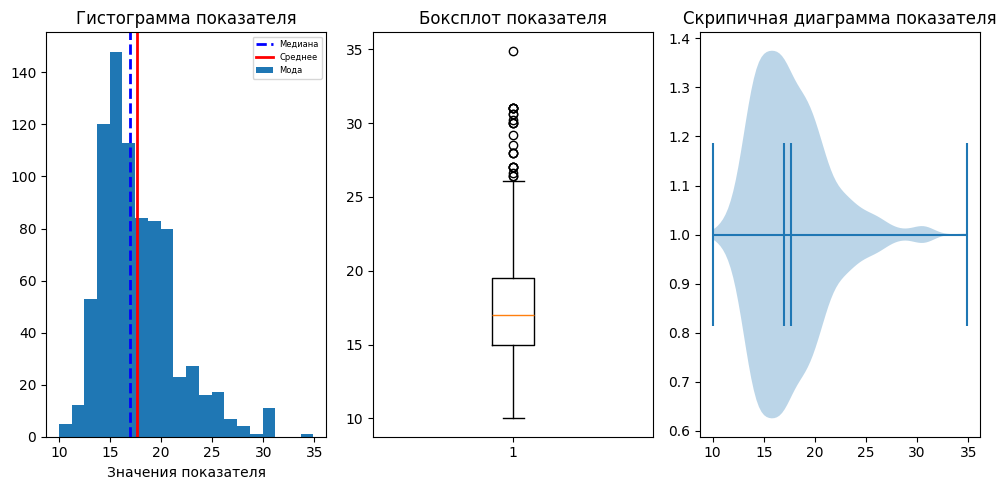

Показатели описательной статистики
count    805.000000
mean      17.667665
std        3.710298
min       10.000000
25%       15.000000
50%       17.000000
75%       19.500000
max       34.900000
Name: rdw, dtype: float64
Мода в данных по показателю: 0    14.0
Name: rdw, dtype: float64
----------------------------------------------------------------------------------------------------
Исследовательский анализ показателя ret_abs


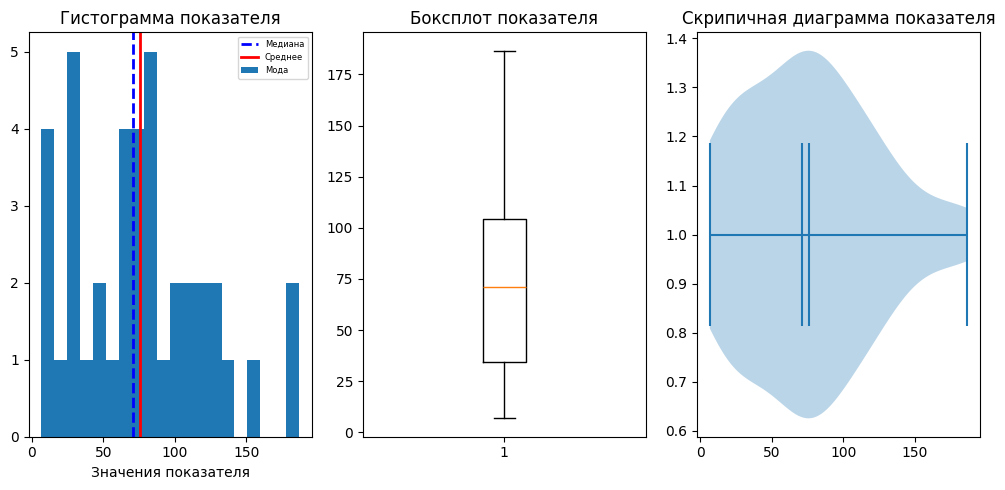

Показатели описательной статистики
count     40.00000
mean      75.83500
std       45.84016
min        6.80000
25%       34.12500
50%       71.10000
75%      104.45000
max      186.60000
Name: ret_abs, dtype: float64
Мода в данных по показателю: 0    68.8
1    71.1
Name: ret_abs, dtype: float64
----------------------------------------------------------------------------------------------------
Исследовательский анализ показателя ret_rel


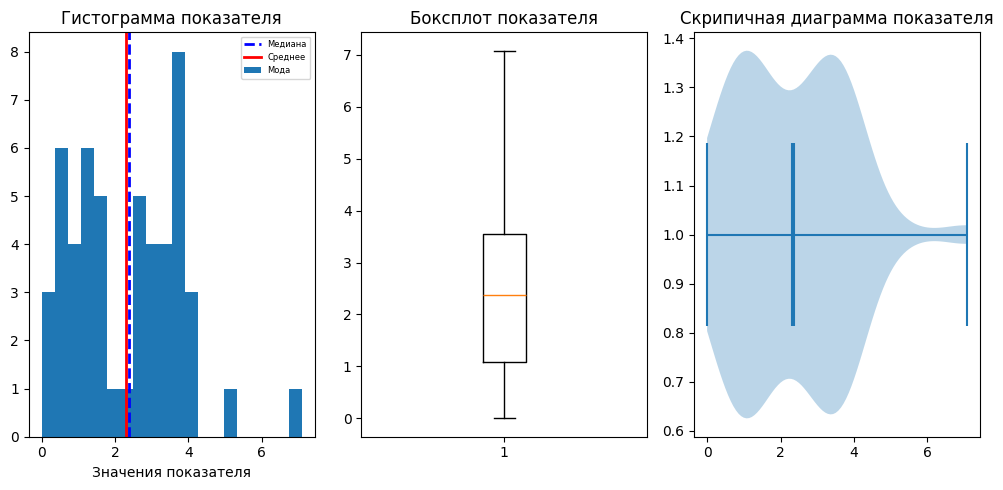

Показатели описательной статистики
count    52.000000
mean      2.311923
std       1.504082
min       0.000000
25%       1.080000
50%       2.370000
75%       3.555000
max       7.080000
Name: ret_rel, dtype: float64
Мода в данных по показателю: 0    2.79
1    3.70
Name: ret_rel, dtype: float64
----------------------------------------------------------------------------------------------------
Исследовательский анализ показателя seg


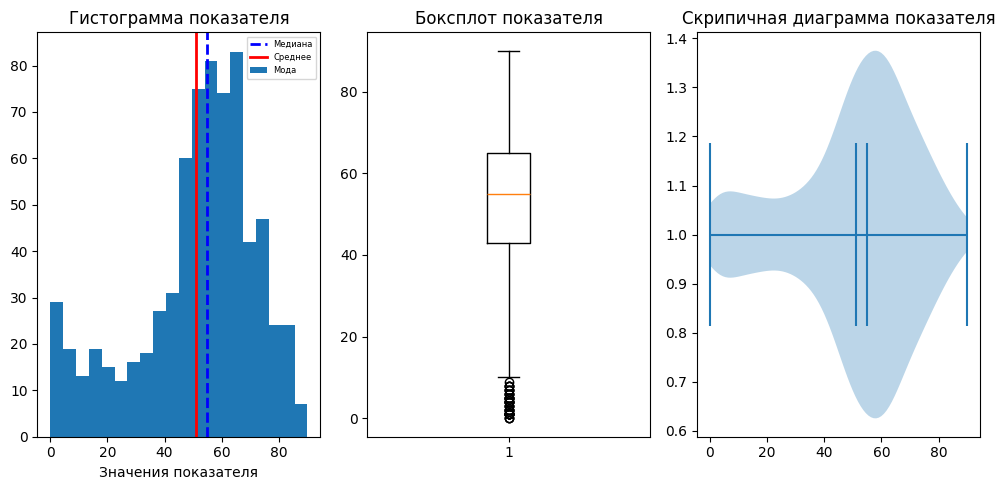

Показатели описательной статистики
count    716.000000
mean      51.089385
std       20.956524
min        0.000000
25%       43.000000
50%       55.000000
75%       65.000000
max       90.000000
Name: seg, dtype: float64
Мода в данных по показателю: 0    60.0
Name: seg, dtype: float64
----------------------------------------------------------------------------------------------------
Исследовательский анализ показателя soe


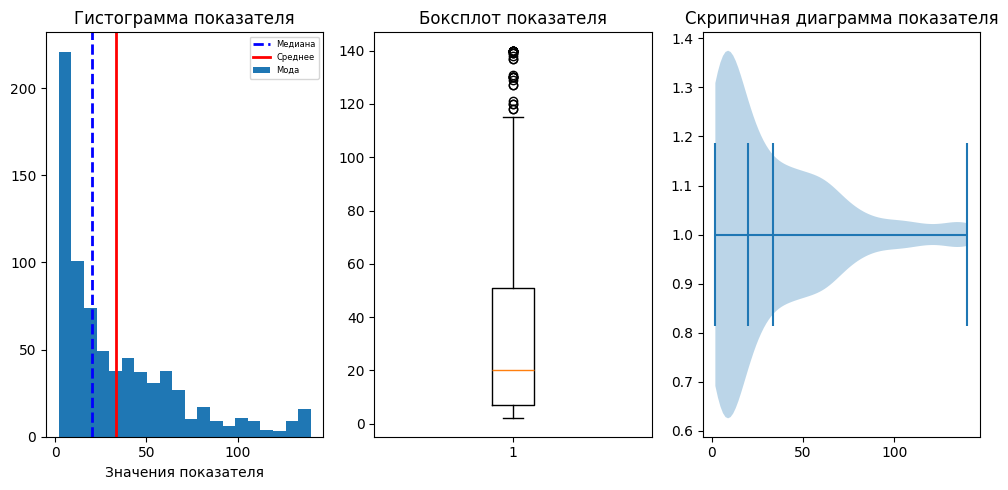

Показатели описательной статистики
count    755.000000
mean      33.505960
std       33.596583
min        2.000000
25%        7.000000
50%       20.000000
75%       51.000000
max      140.000000
Name: soe, dtype: float64
Мода в данных по показателю: 0    4.0
Name: soe, dtype: float64
----------------------------------------------------------------------------------------------------
Исследовательский анализ показателя wbc


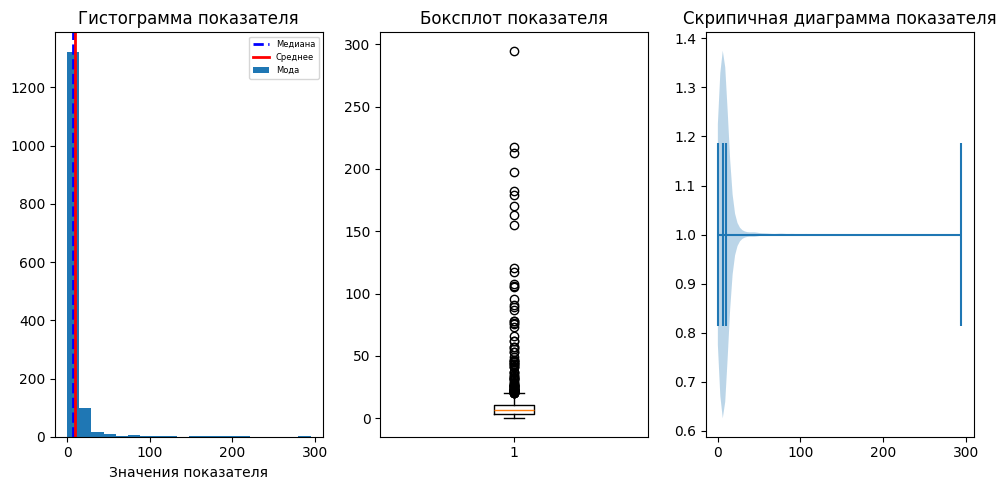

Показатели описательной статистики
count    1477.000000
mean        9.891462
std        18.695870
min         0.000000
25%         3.810000
50%         6.640000
75%        10.300000
max       294.770000
Name: wbc, dtype: float64
Мода в данных по показателю: 0    1.0
Name: wbc, dtype: float64
----------------------------------------------------------------------------------------------------
Исследовательский анализ показателя yunye


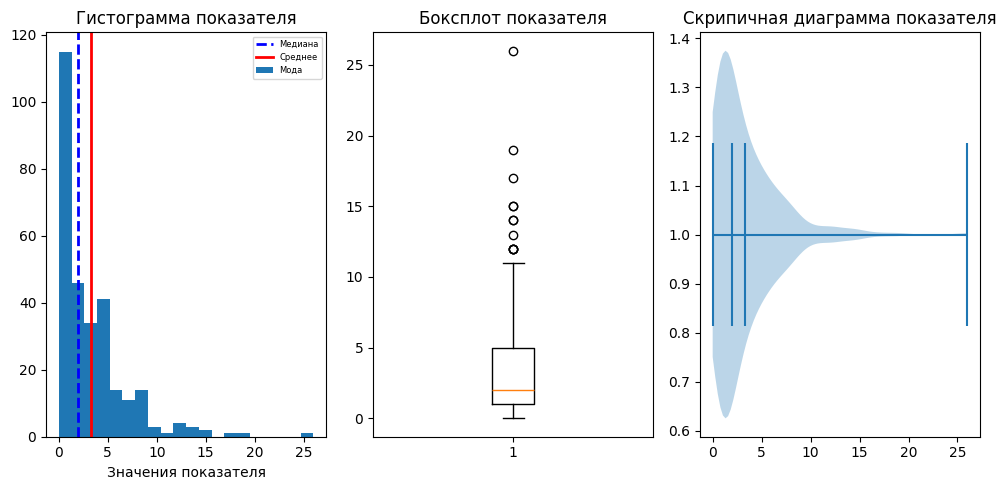

Показатели описательной статистики
count    291.000000
mean       3.303093
std        3.502761
min        0.000000
25%        1.000000
50%        2.000000
75%        5.000000
max       26.000000
Name: yunye, dtype: float64
Мода в данных по показателю: 0    1.0
Name: yunye, dtype: float64
----------------------------------------------------------------------------------------------------


In [20]:
for col in num_col:
  print(f'Исследовательский анализ показателя {col}')
  analisys_num(work_df[col])
  print('-'*100)

Исследовательский анализ показателя prolym


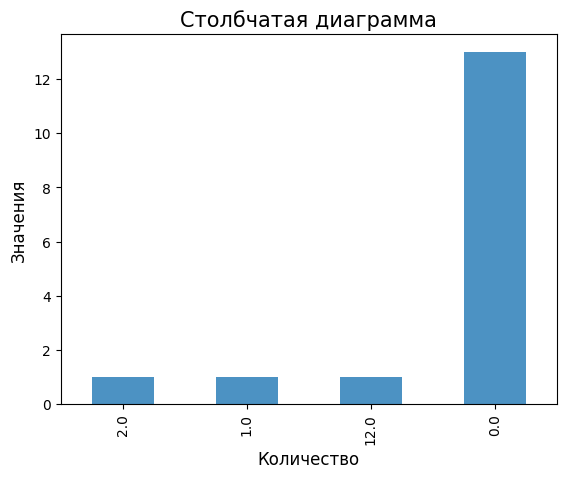

----------------------------------------------------------------------------------------------------
Исследовательский анализ показателя promyelo


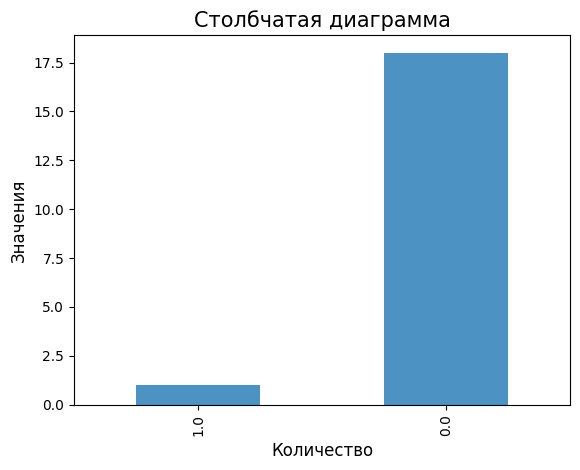

----------------------------------------------------------------------------------------------------


In [21]:
for col in cat_col:
  print(f'Исследовательский анализ показателя {col}')
  analisys_cat_plot(work_df[col])
  print('-'*100)

Исследовательский анализ показателя gender


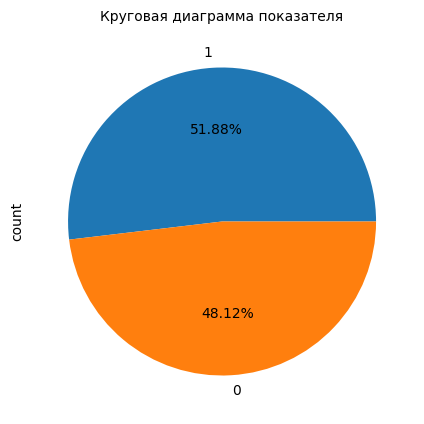

----------------------------------------------------------------------------------------------------
Исследовательский анализ показателя promyelo


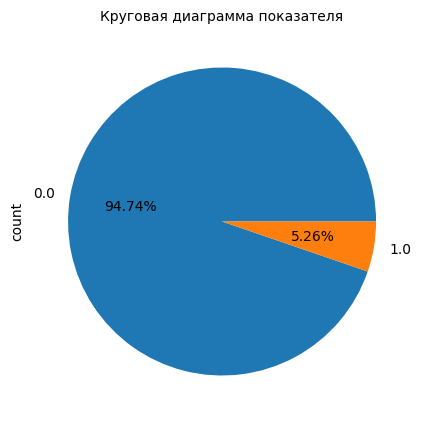

----------------------------------------------------------------------------------------------------
Исследовательский анализ показателя anisocytos


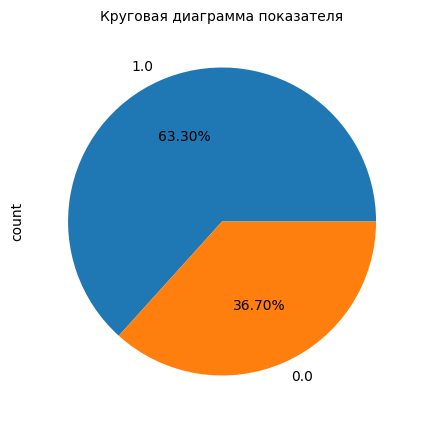

----------------------------------------------------------------------------------------------------
Исследовательский анализ показателя hypochromia


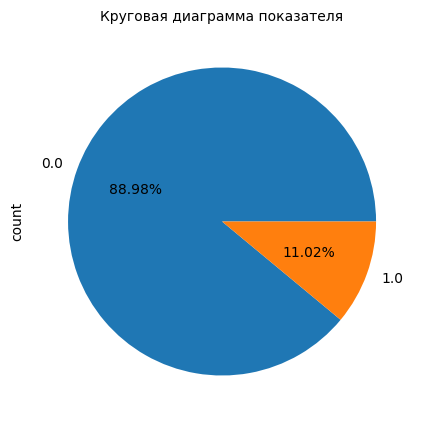

----------------------------------------------------------------------------------------------------
Исследовательский анализ показателя macrocytos


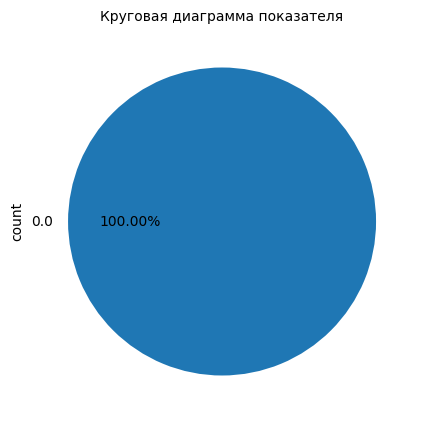

----------------------------------------------------------------------------------------------------
Исследовательский анализ показателя microcytos


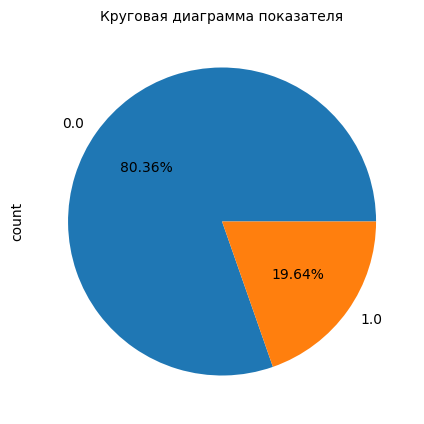

----------------------------------------------------------------------------------------------------
Исследовательский анализ показателя normoblast


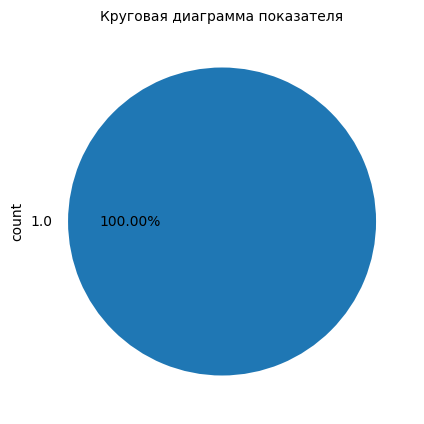

----------------------------------------------------------------------------------------------------
Исследовательский анализ показателя poikilocytos


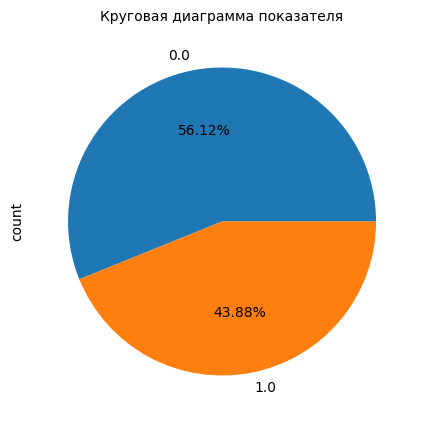

----------------------------------------------------------------------------------------------------
Исследовательский анализ показателя normobl_rel


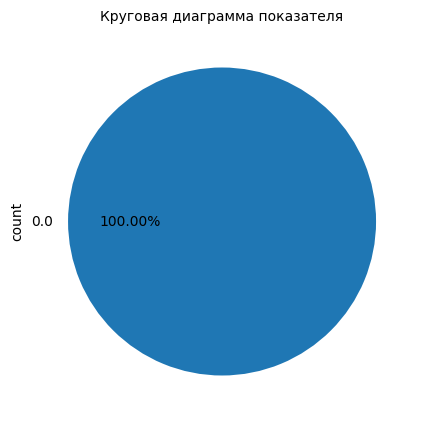

----------------------------------------------------------------------------------------------------


In [22]:
for col in bool_col:
  print(f'Исследовательский анализ показателя {col}')
  analisys_cat_pie(work_df[col])
  print('-'*100)

In [23]:
work_df.shape

(3115, 52)

In [24]:
work_df = work_df.drop(['normoblast', 'normobl_rel', 'macrocytos'], axis = 1)

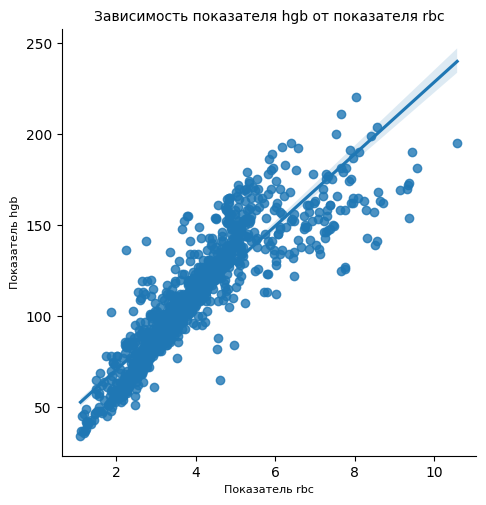

In [25]:
grafic(work_df, 'rbc', 'hgb')

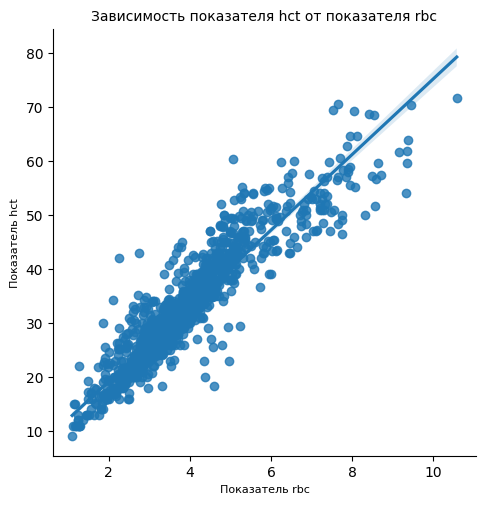

In [26]:
grafic(work_df, 'rbc', 'hct')

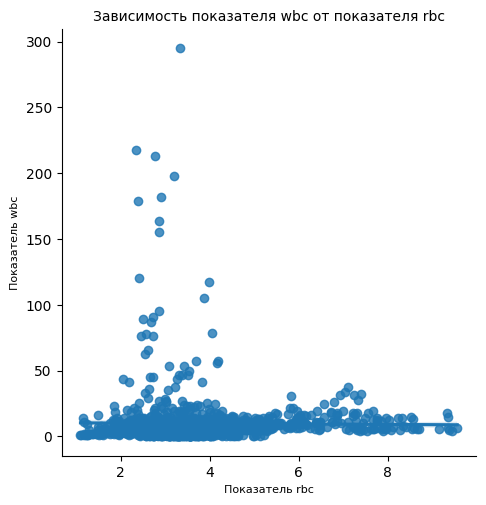

In [27]:
grafic(work_df, 'rbc', 'wbc')

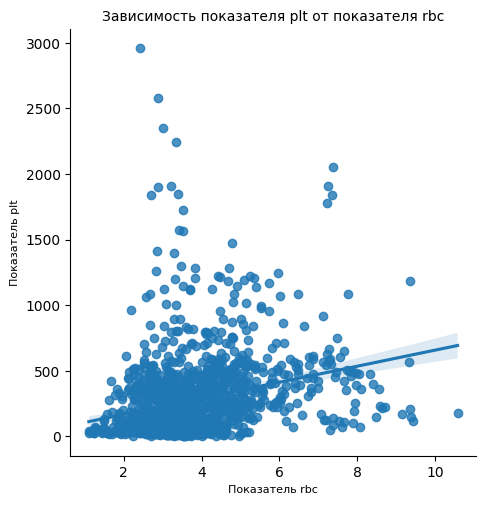

In [28]:
grafic(work_df, 'rbc', 'plt')

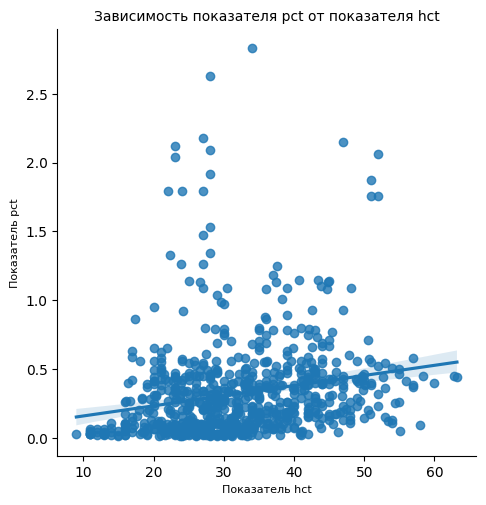

In [29]:
grafic(work_df, 'hct', 'pct')

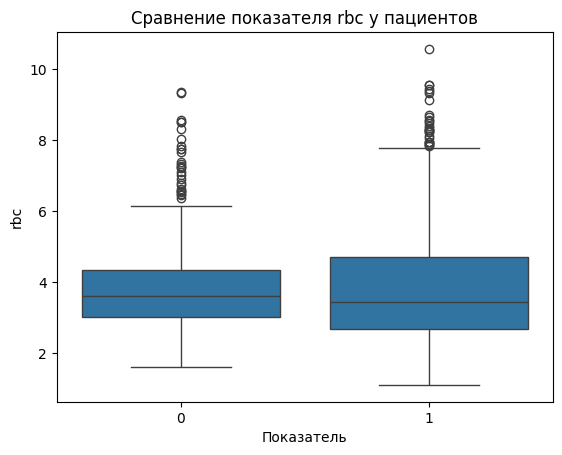

In [30]:
target_sigh(work_df, 'gender', 'rbc')

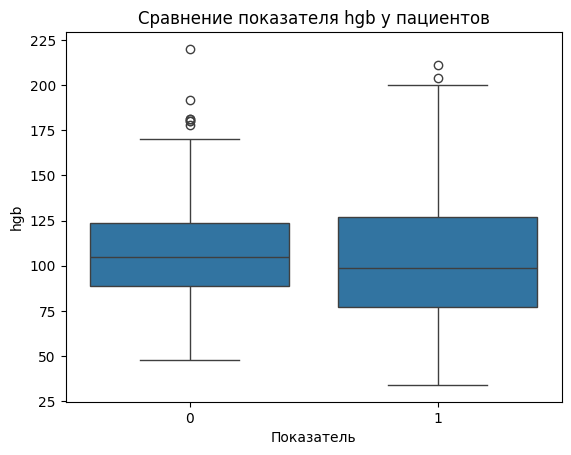

In [31]:
target_sigh(work_df, 'gender', 'hgb')

Сравнение распределения показателя ba_abs внутри
 представителей разного покда


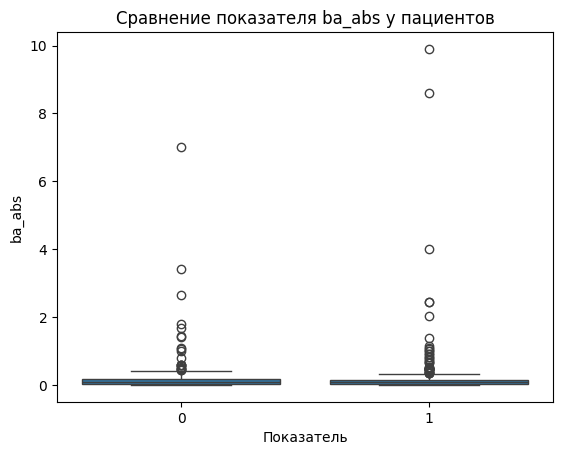

----------------------------------------------------------------------------------------------------
Сравнение распределения показателя ba_rel внутри
 представителей разного покда


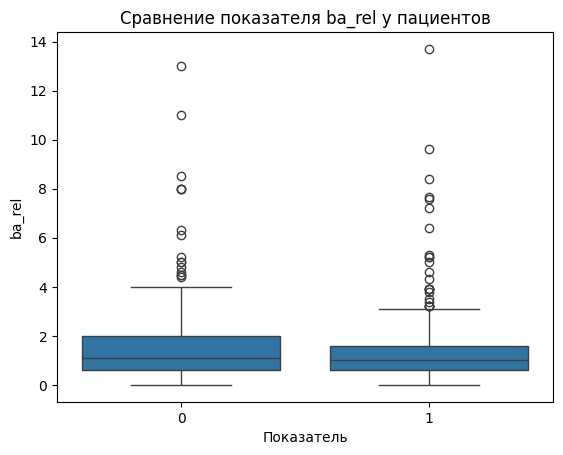

----------------------------------------------------------------------------------------------------
Сравнение распределения показателя blasty внутри
 представителей разного покда


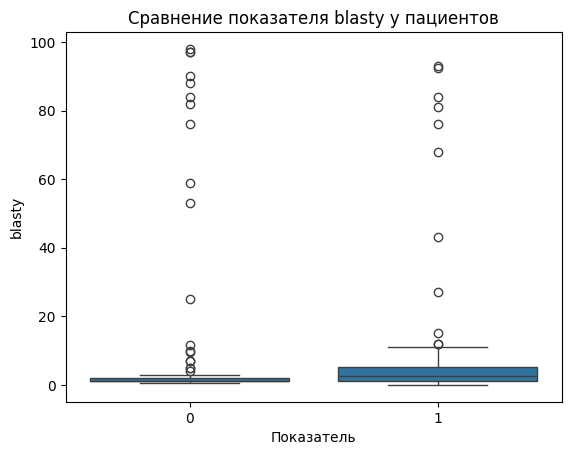

----------------------------------------------------------------------------------------------------
Сравнение распределения показателя cp внутри
 представителей разного покда


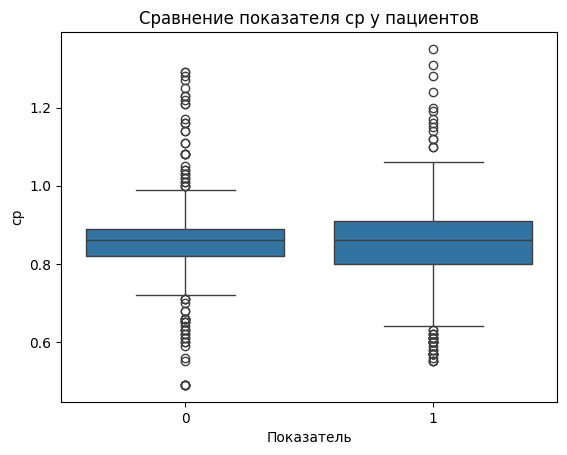

----------------------------------------------------------------------------------------------------
Сравнение распределения показателя eo_abs внутри
 представителей разного покда


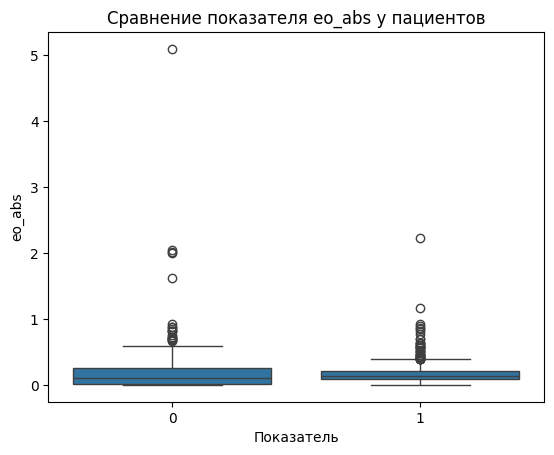

----------------------------------------------------------------------------------------------------
Сравнение распределения показателя eo_rel внутри
 представителей разного покда


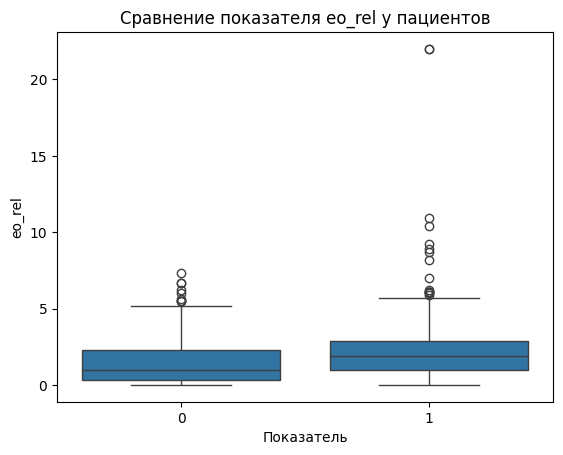

----------------------------------------------------------------------------------------------------
Сравнение распределения показателя hct внутри
 представителей разного покда


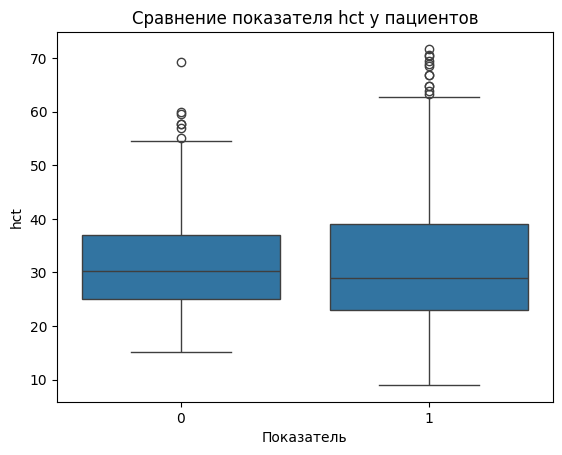

----------------------------------------------------------------------------------------------------
Сравнение распределения показателя hgb внутри
 представителей разного покда


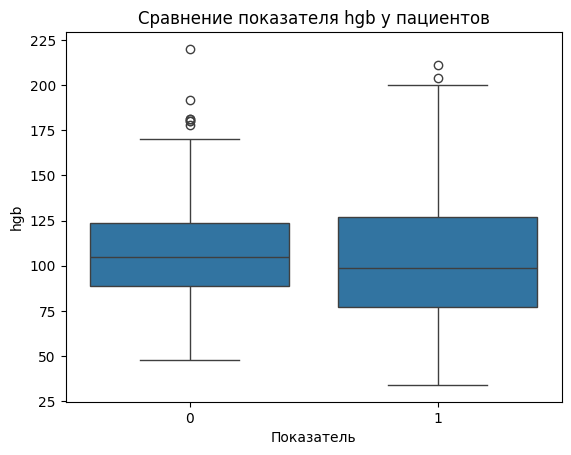

----------------------------------------------------------------------------------------------------
Сравнение распределения показателя ly_abs внутри
 представителей разного покда


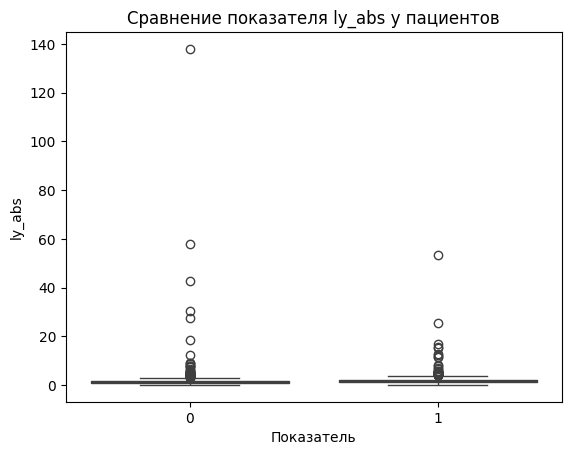

----------------------------------------------------------------------------------------------------
Сравнение распределения показателя ly_rel внутри
 представителей разного покда


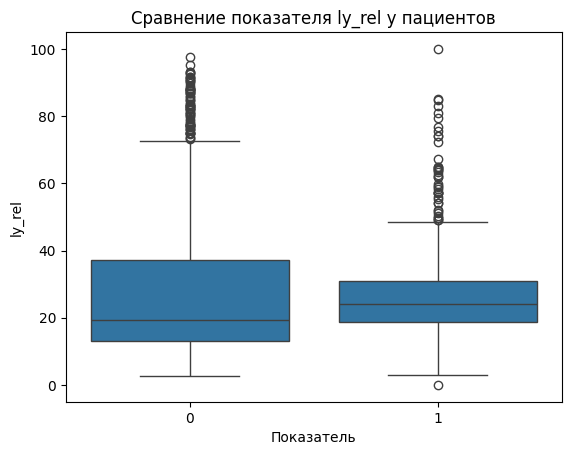

----------------------------------------------------------------------------------------------------
Сравнение распределения показателя mch внутри
 представителей разного покда


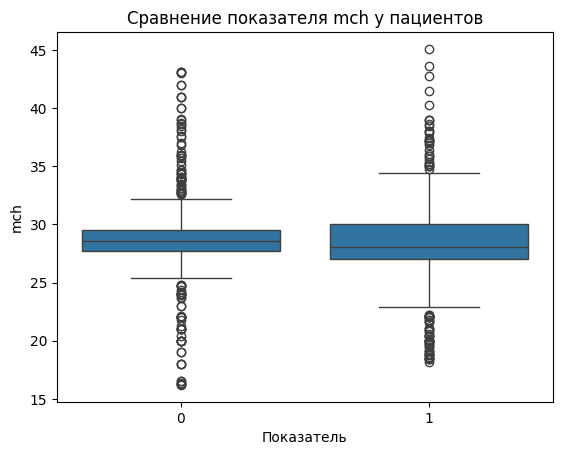

----------------------------------------------------------------------------------------------------
Сравнение распределения показателя mchc внутри
 представителей разного покда


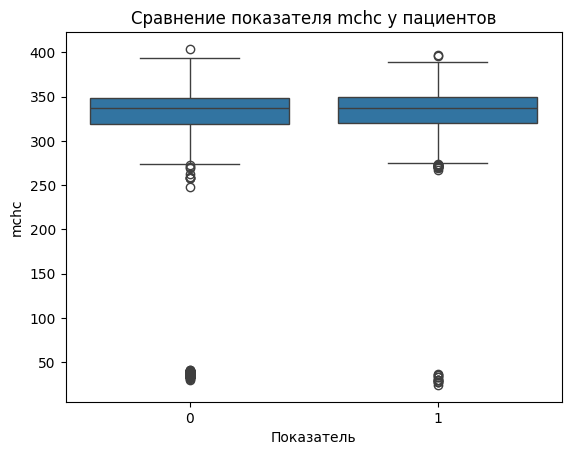

----------------------------------------------------------------------------------------------------
Сравнение распределения показателя mcv внутри
 представителей разного покда


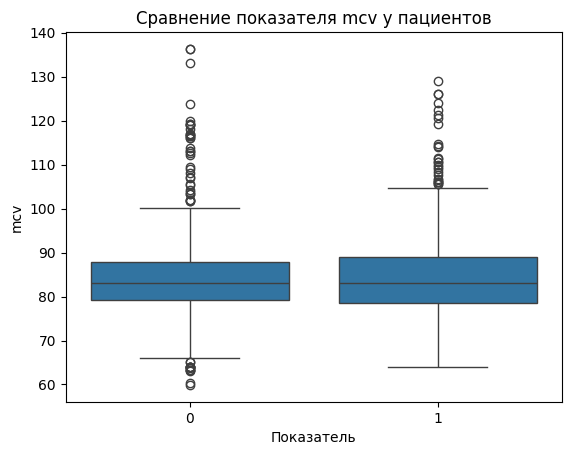

----------------------------------------------------------------------------------------------------
Сравнение распределения показателя mo_abs внутри
 представителей разного покда


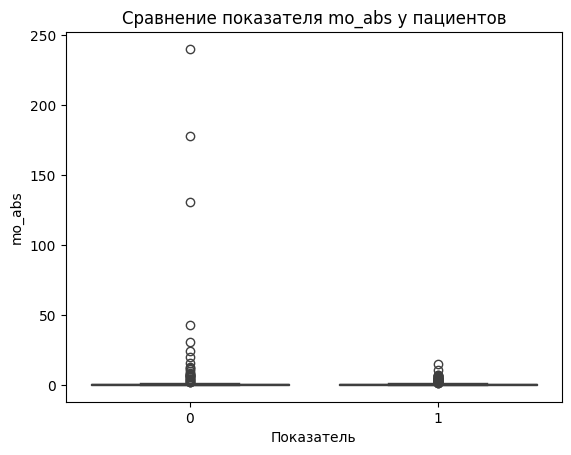

----------------------------------------------------------------------------------------------------
Сравнение распределения показателя mo_rel внутри
 представителей разного покда


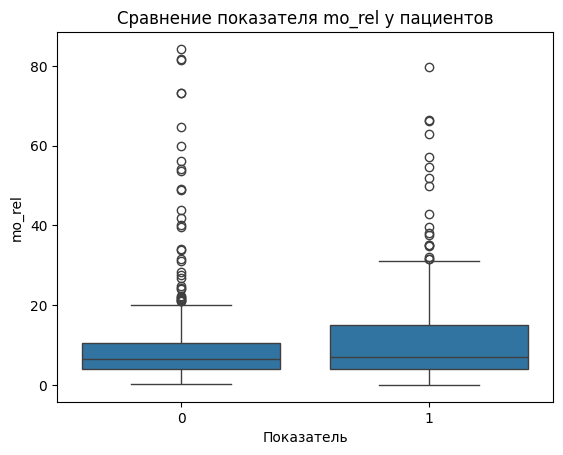

----------------------------------------------------------------------------------------------------
Сравнение распределения показателя mpv внутри
 представителей разного покда


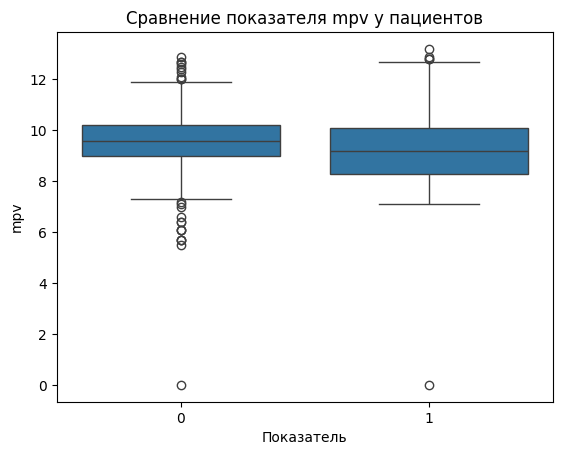

----------------------------------------------------------------------------------------------------
Сравнение распределения показателя mxd_abs внутри
 представителей разного покда


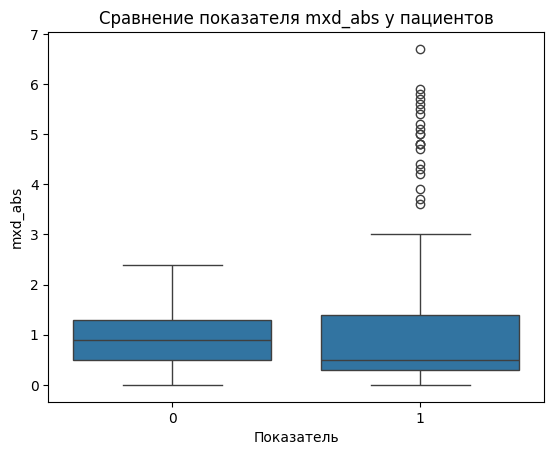

----------------------------------------------------------------------------------------------------
Сравнение распределения показателя mxd_rel внутри
 представителей разного покда


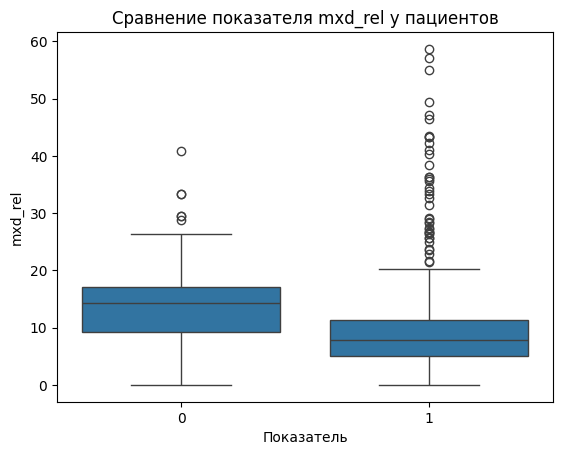

----------------------------------------------------------------------------------------------------
Сравнение распределения показателя myelo внутри
 представителей разного покда


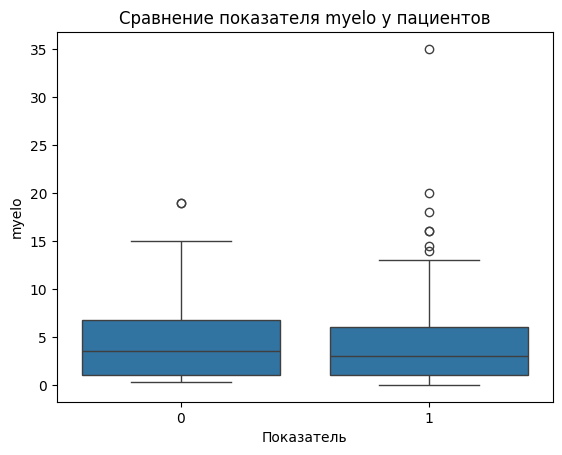

----------------------------------------------------------------------------------------------------
Сравнение распределения показателя ne_abs внутри
 представителей разного покда


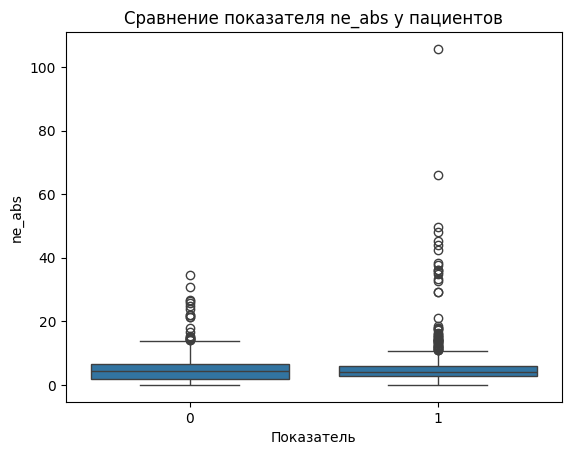

----------------------------------------------------------------------------------------------------
Сравнение распределения показателя ne_rel внутри
 представителей разного покда


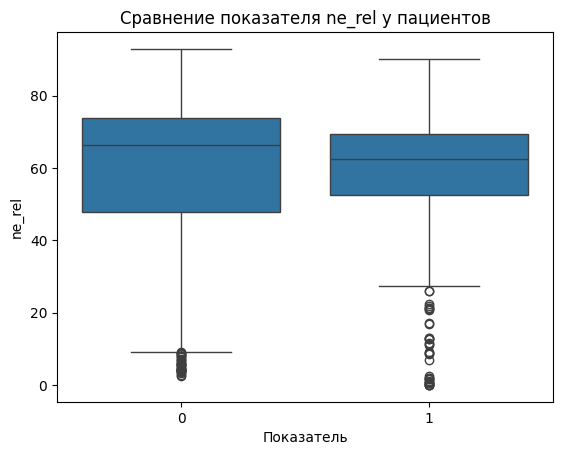

----------------------------------------------------------------------------------------------------
Сравнение распределения показателя noclass_abs внутри
 представителей разного покда


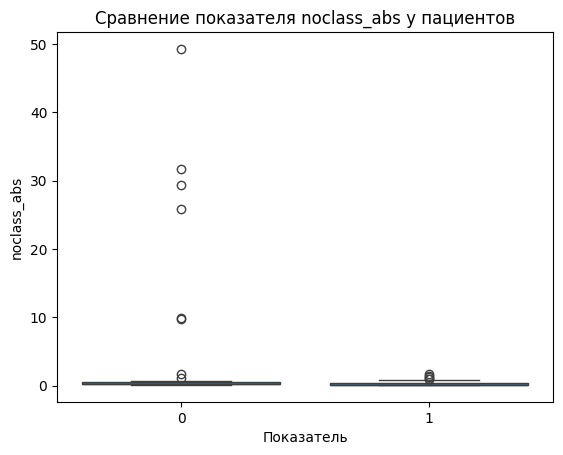

----------------------------------------------------------------------------------------------------
Сравнение распределения показателя noclass_rel внутри
 представителей разного покда


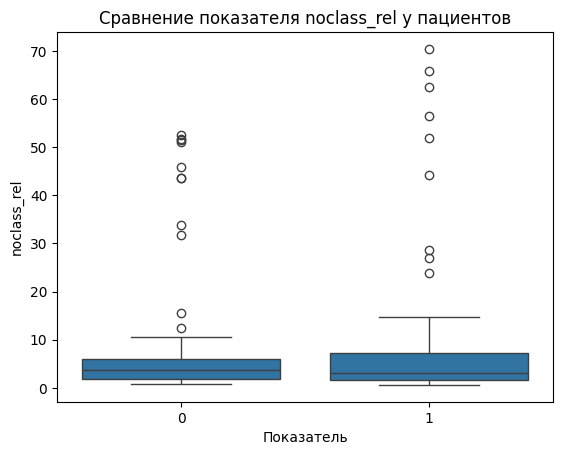

----------------------------------------------------------------------------------------------------
Сравнение распределения показателя normobl_abs внутри
 представителей разного покда


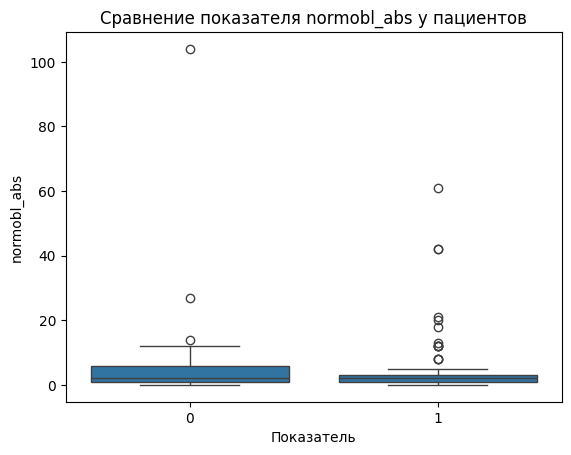

----------------------------------------------------------------------------------------------------
Сравнение распределения показателя pal внутри
 представителей разного покда


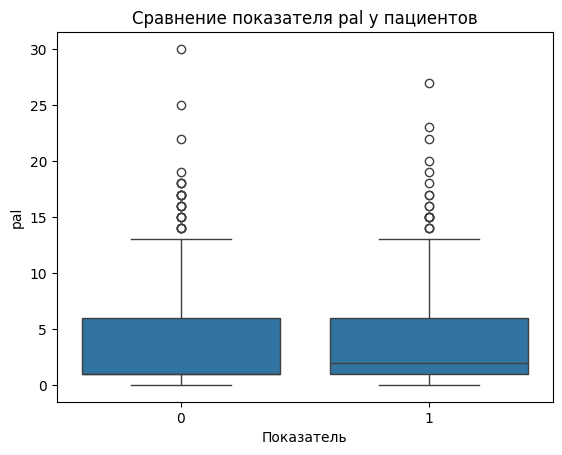

----------------------------------------------------------------------------------------------------
Сравнение распределения показателя pct внутри
 представителей разного покда


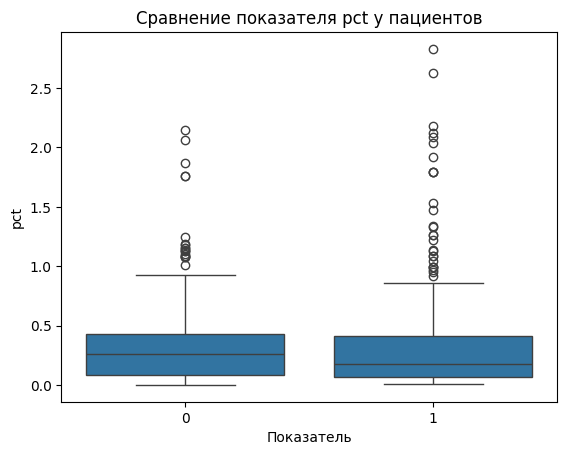

----------------------------------------------------------------------------------------------------
Сравнение распределения показателя pdw внутри
 представителей разного покда


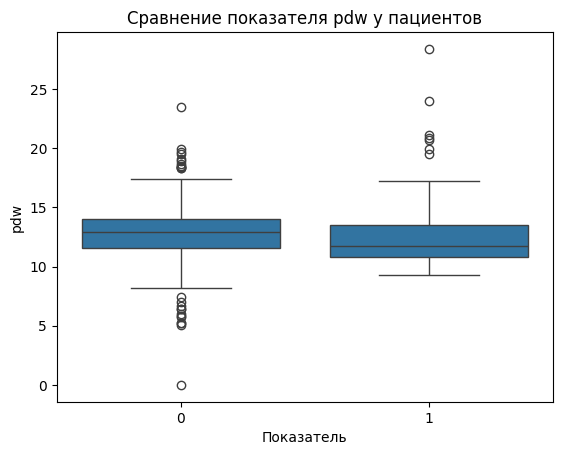

----------------------------------------------------------------------------------------------------
Сравнение распределения показателя plasma внутри
 представителей разного покда


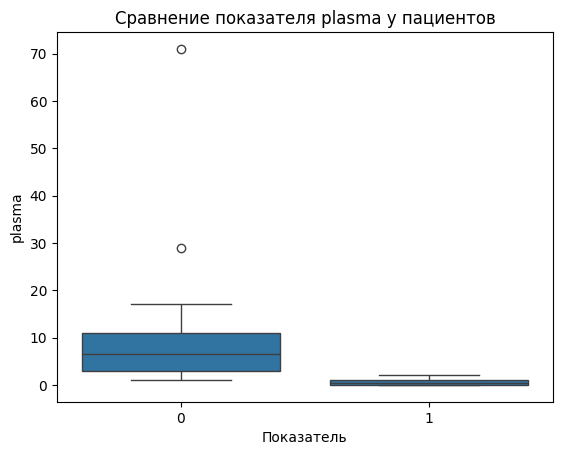

----------------------------------------------------------------------------------------------------
Сравнение распределения показателя plcr внутри
 представителей разного покда


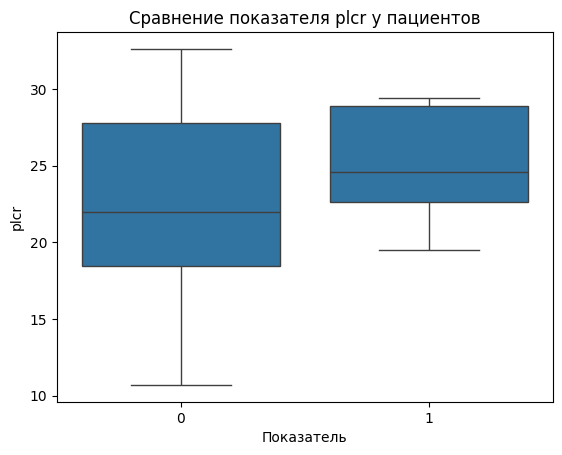

----------------------------------------------------------------------------------------------------
Сравнение распределения показателя plt внутри
 представителей разного покда


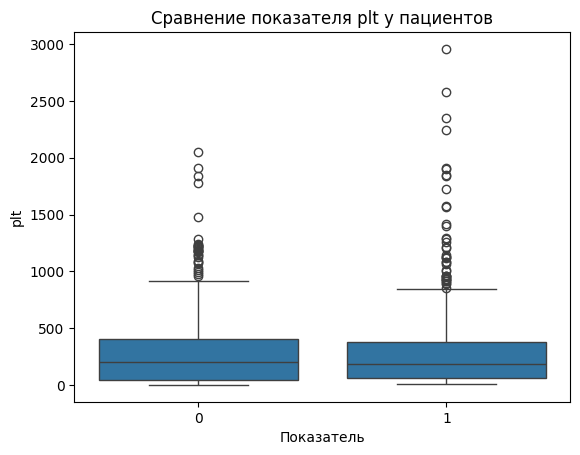

----------------------------------------------------------------------------------------------------
Сравнение распределения показателя rbc внутри
 представителей разного покда


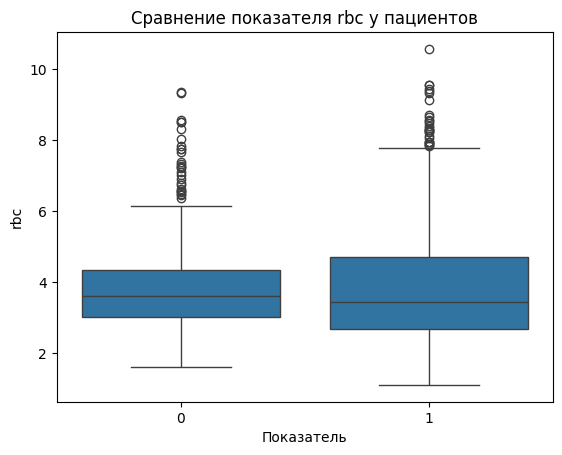

----------------------------------------------------------------------------------------------------
Сравнение распределения показателя rdv_cv внутри
 представителей разного покда


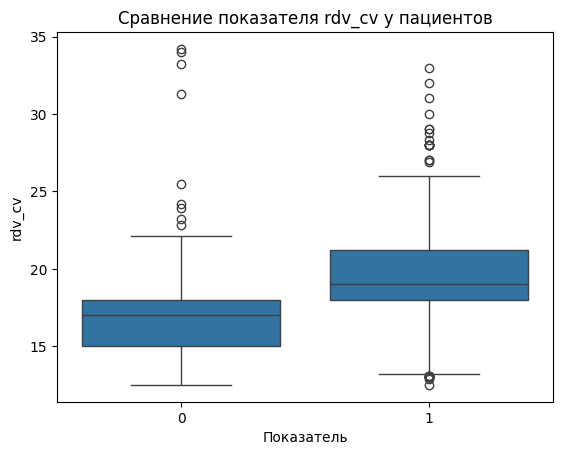

----------------------------------------------------------------------------------------------------
Сравнение распределения показателя rdv_sd внутри
 представителей разного покда


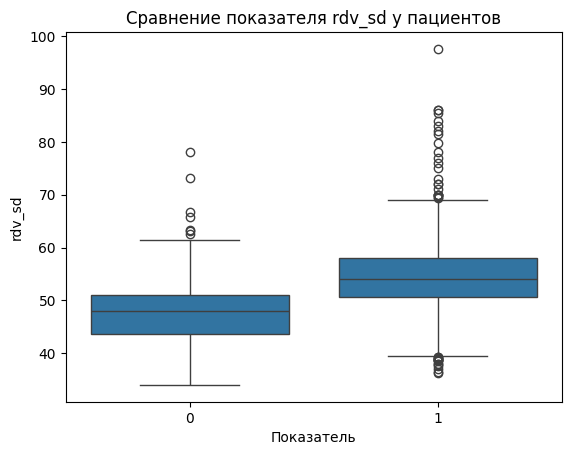

----------------------------------------------------------------------------------------------------
Сравнение распределения показателя rdw внутри
 представителей разного покда


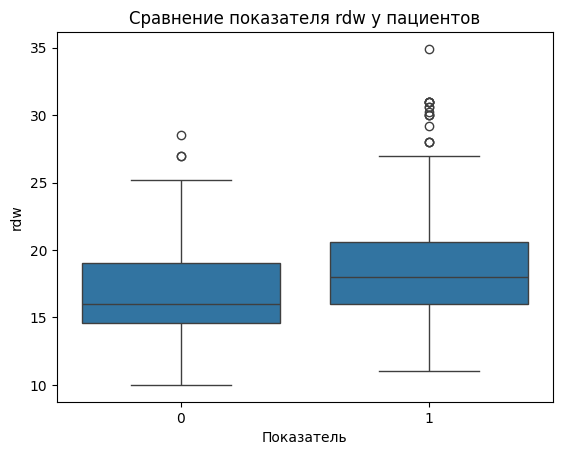

----------------------------------------------------------------------------------------------------
Сравнение распределения показателя ret_abs внутри
 представителей разного покда


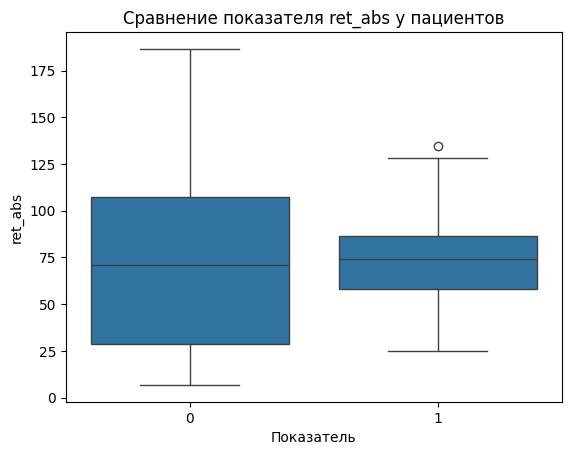

----------------------------------------------------------------------------------------------------
Сравнение распределения показателя ret_rel внутри
 представителей разного покда


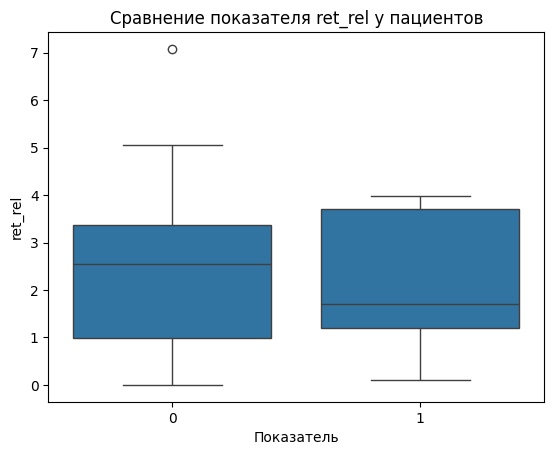

----------------------------------------------------------------------------------------------------
Сравнение распределения показателя seg внутри
 представителей разного покда


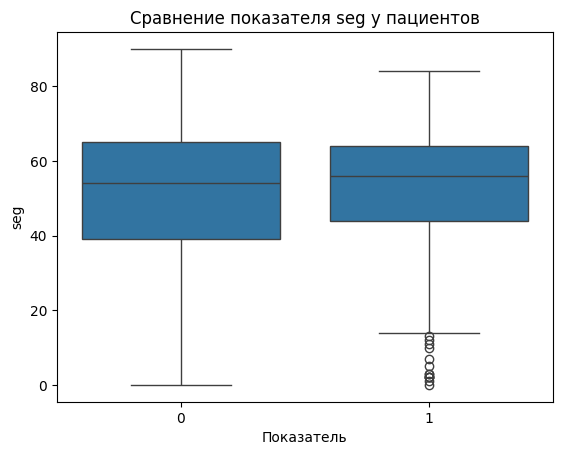

----------------------------------------------------------------------------------------------------
Сравнение распределения показателя soe внутри
 представителей разного покда


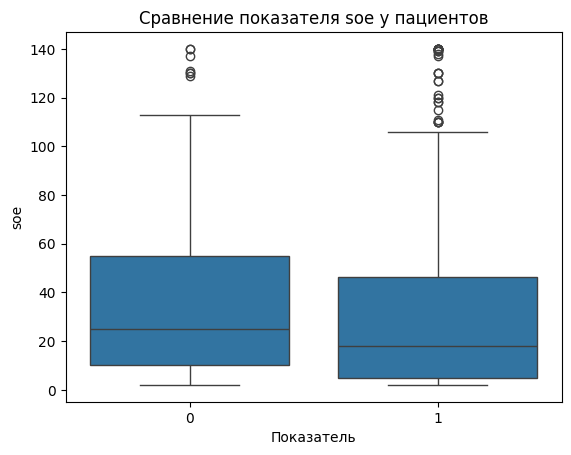

----------------------------------------------------------------------------------------------------
Сравнение распределения показателя wbc внутри
 представителей разного покда


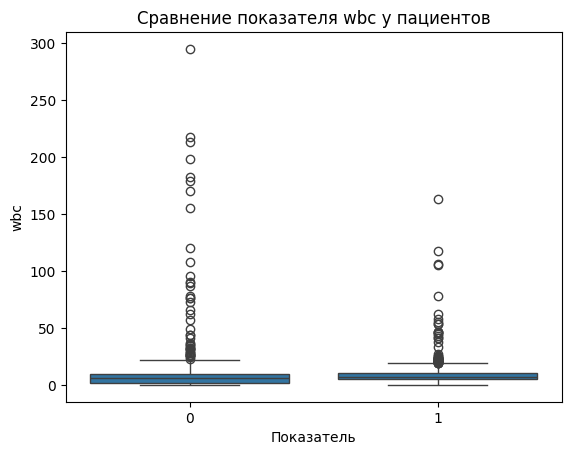

----------------------------------------------------------------------------------------------------
Сравнение распределения показателя yunye внутри
 представителей разного покда


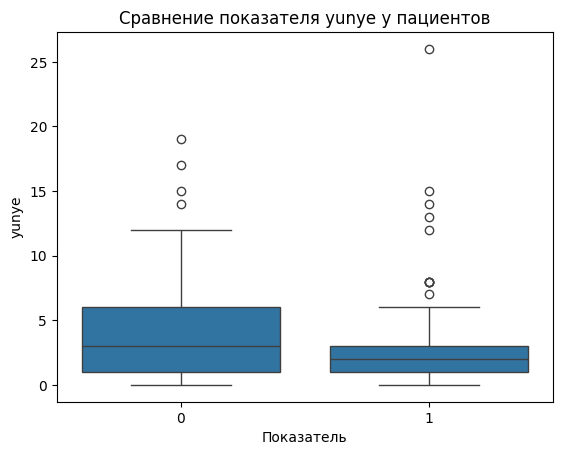

----------------------------------------------------------------------------------------------------


In [32]:
for col in num_col:
  print(f'Сравнение распределения показателя {col} внутри\n представителей разного покда')
  target_sigh(work_df, 'gender', col)
  print('-'*100)

In [33]:
#подготовка данных для корреляции
#в связи с большим количеством данных и разбросом данных, не расчитать ранги
df_cleaned = work_df.drop('study_ID', axis=1)
df_cleaned = df_cleaned.fillna(df_cleaned.median())

scaler = StandardScaler()
scaled_data = scaler.fit_transform(df_cleaned)

In [34]:
# QR-разложение для определения ранга корреляции
Q, R = np.linalg.qr(scaled_data)
qr_rank = np.sum(np.abs(R.diagonal()) > 1e-10)

print(f'QR-разложение (количество линейно независимых столбцов): {qr_rank}')
print(f'Количество столбцов: {scaled_data.shape[1]}')

QR-разложение (количество линейно независимых столбцов): 48
Количество столбцов: 48


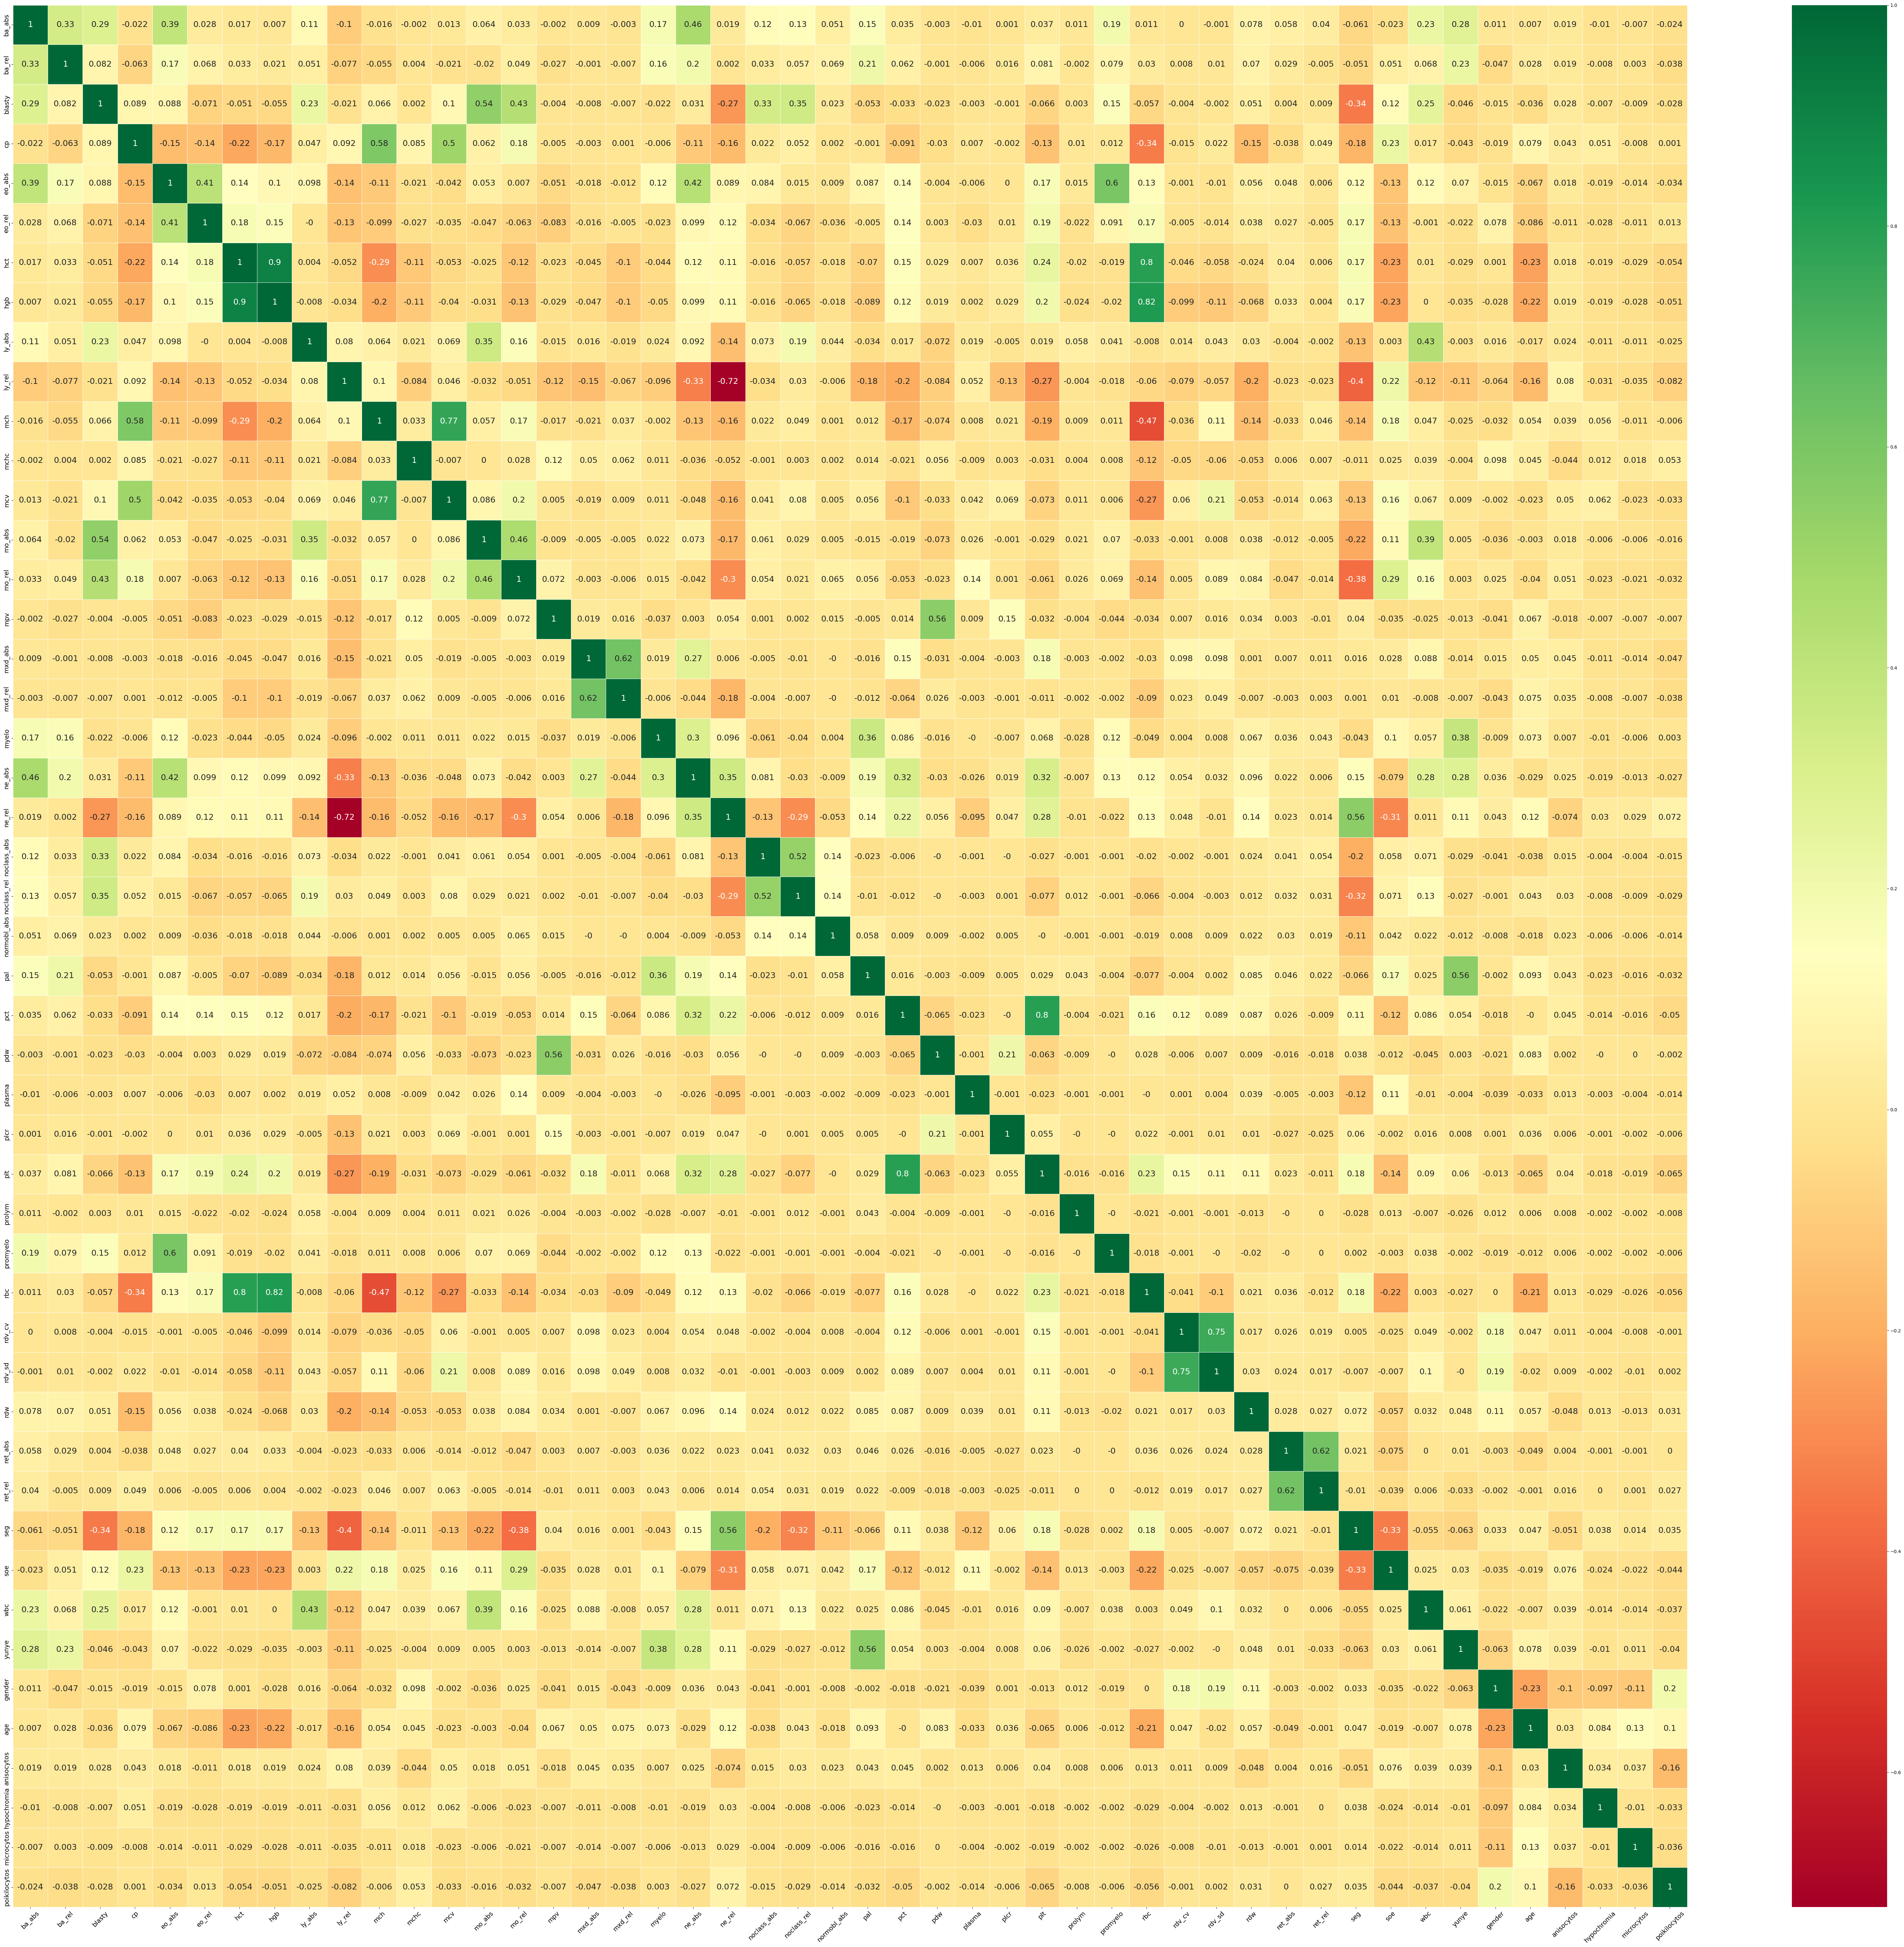

In [35]:
corr_matrix_df = round(df_cleaned.corr(), 3)

fig, ax = plt.subplots(figsize=(65, 60))
sns.heatmap(
    corr_matrix_df,
    annot=True,
    cmap='RdYlGn',
    annot_kws={"fontsize": 18},
    xticklabels=corr_matrix_df.columns,
    yticklabels=corr_matrix_df.index,
    linewidths=.5
)
ax.tick_params(axis="x", labelrotation=45, labelsize=14)
ax.tick_params(axis="y", labelsize=14)
plt.tight_layout()
plt.show()

In [36]:
#выведем пары с корреляцией выше 0.5
threshold = 0.5

high_correlations = (
    corr_matrix_df
    .stack()
    .reset_index()
    .rename(columns={0:'Корреляция'})
    .query('level_0 != level_1')
    .query(f'abs(Корреляция) >= {threshold}')
)

result = high_correlations.sort_values(by='Корреляция', ascending=False)[['level_0', 'level_1', 'Корреляция']]
display(result)


,level_0,level_1,Корреляция
295,hct,hgb,0.904
342,hgb,hct,0.904
368,hgb,rbc,0.818
1543,rbc,hgb,0.818
1417,plt,pct,0.798
1229,pct,plt,0.798
1542,rbc,hct,0.795
320,hct,rbc,0.795
586,mcv,mch,0.770
492,mch,mcv,0.770


In [37]:
print('Код не упал!')

Код не упал!
